In [60]:
from pathlib import Path
import warnings
import sys
import subprocess

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from scipy import stats
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy"])
    from scipy import stats

sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [61]:
DATA_PATH = Path("../../data/m5-forecasting-accuracy/processed/m5_store_dept_daily_with_weather.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/m5-forecasting-accuracy/processed/m5_store_dept_daily_with_weather.csv")

df = pd.read_csv(DATA_PATH, parse_dates=["date"], low_memory=False)
display(df.head())

,date,d,wm_yr_wk,store_id,state_id,cat_id,dept_id,daily_revenue,daily_units,item_count,active_item_count,weighted_avg_sell_price,has_sales,weekday,wday,month,year,quarter,week_of_year,day_of_month,day_of_year,day_of_week,day_of_week_num,is_weekend,year_month,event_name_1,event_type_1,event_name_2,event_type_2,event_count,snap_CA,snap_TX,snap_WI,snap_active,weather_location_id,location_name,weather_spatial_level,weather_code,temperature_max_c,temperature_min_c,temperature_mean_c,apparent_temperature_mean_c,precipitation_mm,rain_mm,snowfall_cm,wind_speed_max_kmh,wind_gusts_max_kmh,shortwave_radiation_mj_m2,latitude_requested,longitude_requested,latitude_open_meteo,longitude_open_meteo,elevation_m,timezone,utc_offset_seconds,weather_source
0,2011-01-29,d_1,11101,CA_1,CA,FOODS,FOODS_1,681.1800,297,216,70,2.2935,1,Saturday,1,1,2011,1,4,29,29,Saturday,5,1,2011-01,NaN,NaN,NaN,NaN,0,0,0,0,0,m5_CA,"Los Angeles, CA",state_representative_city,3,18.1000,6.1000,11.7000,9.7000,0.0000,0.0000,0.0000,10.9000,25.9000,14.8100,34.0522,-118.2437,34.0598,-118.2375,91.0000,America/Los_Angeles,-25200,open_meteo_archive
1,2011-01-29,d_1,11101,CA_1,CA,FOODS,FOODS_2,"2,236.0100",674,398,154,3.3175,1,Saturday,1,1,2011,1,4,29,29,Saturday,5,1,2011-01,NaN,NaN,NaN,NaN,0,0,0,0,0,m5_CA,"Los Angeles, CA",state_representative_city,3,18.1000,6.1000,11.7000,9.7000,0.0000,0.0000,0.0000,10.9000,25.9000,14.8100,34.0522,-118.2437,34.0598,-118.2375,91.0000,America/Los_Angeles,-25200,open_meteo_archive
2,2011-01-29,d_1,11101,CA_1,CA,FOODS,FOODS_3,"4,323.4600",2268,823,285,1.9063,1,Saturday,1,1,2011,1,4,29,29,Saturday,5,1,2011-01,NaN,NaN,NaN,NaN,0,0,0,0,0,m5_CA,"Los Angeles, CA",state_representative_city,3,18.1000,6.1000,11.7000,9.7000,0.0000,0.0000,0.0000,10.9000,25.9000,14.8100,34.0522,-118.2437,34.0598,-118.2375,91.0000,America/Los_Angeles,-25200,open_meteo_archive
3,2011-01-29,d_1,11101,CA_1,CA,HOBBIES,HOBBIES_1,"1,276.8600",528,416,101,2.4183,1,Saturday,1,1,2011,1,4,29,29,Saturday,5,1,2011-01,NaN,NaN,NaN,NaN,0,0,0,0,0,m5_CA,"Los Angeles, CA",state_representative_city,3,18.1000,6.1000,11.7000,9.7000,0.0000,0.0000,0.0000,10.9000,25.9000,14.8100,34.0522,-118.2437,34.0598,-118.2375,91.0000,America/Los_Angeles,-25200,open_meteo_archive
4,2011-01-29,d_1,11101,CA_1,CA,HOBBIES,HOBBIES_2,93.0500,28,149,17,3.3232,1,Saturday,1,1,2011,1,4,29,29,Saturday,5,1,2011-01,NaN,NaN,NaN,NaN,0,0,0,0,0,m5_CA,"Los Angeles, CA",state_representative_city,3,18.1000,6.1000,11.7000,9.7000,0.0000,0.0000,0.0000,10.9000,25.9000,14.8100,34.0522,-118.2437,34.0598,-118.2375,91.0000,America/Los_Angeles,-25200,open_meteo_archive


#### 1. Gom nhóm column

In [62]:
grain_cols = ["date", "store_id", "dept_id"]
target_col = "daily_revenue"
weather_feature_cols = [
    "weather_code",
    "temperature_max_c",
    "temperature_min_c",
    "temperature_mean_c",
    "apparent_temperature_mean_c",
    "precipitation_mm",
    "rain_mm",
    "snowfall_cm",
    "wind_speed_max_kmh",
    "wind_gusts_max_kmh",
    "shortwave_radiation_mj_m2",
]
event_cols = ["event_name_1", "event_type_1", "event_name_2", "event_type_2"]
leakage_risk_cols = ["daily_units", "active_item_count", "has_sales", "weighted_avg_sell_price"]


### 2. Overview

In [63]:
overview = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "date_min",
        "date_max",
        "unique_dates",
        "unique_states",
        "unique_stores",
        "unique_categories",
        "unique_departments",
    ],
    "value": [
        df.shape[0],
        df.shape[1],
        df["date"].min(),
        df["date"].max(),
        df["date"].nunique(),
        df["state_id"].nunique(),
        df["store_id"].nunique(),
        df["cat_id"].nunique(),
        df["dept_id"].nunique(),
    ],
})

display(overview)

,metric,value
0,rows,135870
1,columns,56
2,date_min,2011-01-29 00:00:00
3,date_max,2016-05-22 00:00:00
4,unique_dates,1941
5,unique_states,3
6,unique_stores,10
7,unique_categories,3
8,unique_departments,7


### 3. Missing value

In [64]:
missing_table = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_rate": (df.isna().sum().values / len(df))
})

missing_table = missing_table.sort_values("missing_count", ascending=False)

display(missing_table)

,column,missing_count,missing_rate
28,event_type_2,135590,0.9979
27,event_name_2,135590,0.9979
26,event_type_1,124810,0.9186
25,event_name_1,124810,0.9186
11,weighted_avg_sell_price,363,0.0027
41,apparent_temperature_mean_c,0,0.0000
32,snap_WI,0,0.0000
33,snap_active,0,0.0000
34,weather_location_id,0,0.0000
35,location_name,0,0.0000


- Missing ở event biểu thị những ngày không có lễ hội, chứ không phải lỗi
- Missing weighted_avg_sell_price có 363 dòng missing: Missing hợp lý vì có ngày sản phẩm đó không bán được cái nào

In [65]:
df["date"] = pd.to_datetime(df["date"])

date_min = df["date"].min()
date_max = df["date"].max()

full_date_range = pd.date_range(start=date_min, end=date_max, freq="D")
actual_dates = pd.Index(df["date"].drop_duplicates().sort_values())

missing_dates = full_date_range.difference(actual_dates)

print("Ngày bắt đầu:", date_min.date())
print("Ngày kết thúc:", date_max.date())
print("Số ngày kỳ vọng:", len(full_date_range))
print("Số ngày thực tế:", len(actual_dates))
print("Số ngày bị thiếu:", len(missing_dates))

if len(missing_dates) > 0:
    display(pd.DataFrame({"missing_date": missing_dates}))
else:
    print("Không thiếu ngày nào trong khoảng thời gian dữ liệu.")

Ngày bắt đầu: 2011-01-29
Ngày kết thúc: 2016-05-22
Số ngày kỳ vọng: 1941
Số ngày thực tế: 1941
Số ngày bị thiếu: 0
Không thiếu ngày nào trong khoảng thời gian dữ liệu.


### 4. Kiểm tra duplicate và key uniqueness
Grain chính của bảng là `date + store_id + dept_id`. Nếu key này bị duplicate thì target ở cùng một đơn vị phân tích bị lặp, làm sai EDA và modeling.

In [66]:
# Kiểm tra duplicate toàn dòng
full_duplicate_rows = df.duplicated().sum()

# Kiểm tra duplicate theo grain chính
grain_duplicate_rows = df.duplicated(["date", "store_id", "dept_id"]).sum()

# Kiểm tra số ngày có liên tục không
date_range = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
missing_dates = set(date_range) - set(df["date"].unique())

# Tổng hợp kết quả
duplicate_summary = pd.DataFrame({
    "check": [
        "full_duplicate_rows",
        "duplicate_date_store_dept",
        "missing_dates",
        "actual_rows"
    ],
    "value": [
        full_duplicate_rows,
        grain_duplicate_rows,
        len(missing_dates),
        len(df)
    ]
})

display(duplicate_summary)

,check,value
0,full_duplicate_rows,0
1,duplicate_date_store_dept,0
2,missing_dates,0
3,actual_rows,135870


In [67]:
rows_per_date_store = (
    df.groupby(["date", "store_id"])
    .size()
    .reset_index(name="row_count")
)

display(rows_per_date_store["row_count"].value_counts())

row_count
7    19410
Name: count, dtype: int64

Mỗi ngày-mỗi store đều có đủ 7 department

### 5. Kiểm tra range và giá trị bất thường

In [68]:
# 1. Thống kê nhanh các cột số quan trọng
important_numeric_cols = [
    "daily_revenue",
    "daily_units",
    "item_count",
    "active_item_count",
    "weighted_avg_sell_price",
    "temperature_mean_c",
    "precipitation_mm",
    "rain_mm",
    "snowfall_cm",
    "wind_speed_max_kmh"
]

display(df[important_numeric_cols].describe())

,daily_revenue,daily_units,item_count,active_item_count,weighted_avg_sell_price,temperature_mean_c,precipitation_mm,rain_mm,snowfall_cm,wind_speed_max_kmh
count,"135,870.0000","135,870.0000","135,870.0000","135,870.0000","135,507.0000","135,870.0000","135,870.0000","135,870.0000","135,870.0000","135,870.0000"
mean,"1,410.0062",492.5824,435.5714,139.3926,3.2682,15.7061,1.6959,1.6000,0.0731,17.9260
std,"1,384.2343",603.8029,206.2730,107.7646,1.0581,9.6775,5.7740,5.6768,0.6062,7.0786
min,0.0000,0.0000,149.0000,0.0000,0.2000,-22.9000,0.0000,0.0000,0.0000,4.7000
25%,500.7100,136.0000,216.0000,70.0000,2.3848,10.2000,0.0000,0.0000,0.0000,12.6000
50%,985.7900,288.0000,416.0000,111.0000,3.1447,16.8000,0.0000,0.0000,0.0000,15.8000
75%,"1,900.5075",552.0000,532.0000,181.0000,3.9200,22.5000,0.3000,0.2000,0.0000,22.6000
max,"11,198.9500","5,118.0000",823.0000,621.0000,10.9650,37.2000,85.5000,85.5000,14.6300,48.5000


In [69]:
# 2. Kiểm tra các giá trị bất thường cơ bản
range_checks = pd.DataFrame({
    "check": [
        "negative_daily_revenue",
        "zero_daily_revenue",
        "negative_daily_units",
        "active_item_gt_item_count",
        "has_sales_mismatch",
        "negative_temperature_issue",
        "negative_precipitation",
        "negative_wind_speed"
    ],
    "value": [
        (df["daily_revenue"] < 0).sum(),
        (df["daily_revenue"] == 0).sum(),
        (df["daily_units"] < 0).sum(),
        (df["active_item_count"] > df["item_count"]).sum(),
        (df["has_sales"] != (df["daily_units"] > 0).astype(int)).sum(),
        ((df["temperature_min_c"] > df["temperature_mean_c"]) | 
         (df["temperature_mean_c"] > df["temperature_max_c"])).sum(),
        (df["precipitation_mm"] < 0).sum(),
        (df["wind_speed_max_kmh"] < 0).sum()
    ]
})

display(range_checks)

,check,value
0,negative_daily_revenue,0
1,zero_daily_revenue,363
2,negative_daily_units,0
3,active_item_gt_item_count,0
4,has_sales_mismatch,0
5,negative_temperature_issue,0
6,negative_precipitation,0
7,negative_wind_speed,0


In [70]:
# 3. Kiểm tra outlier doanh thu theo IQR
q1 = df["daily_revenue"].quantile(0.25)
q3 = df["daily_revenue"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_rows = df[
    (df["daily_revenue"] < lower) |
    (df["daily_revenue"] > upper)
]

print("Q1:", q1)
print("Q3:", q3)
print("Lower bound:", lower)
print("Upper bound:", upper)
print("Outlier rows:", len(outlier_rows))
print("Outlier rate:", len(outlier_rows) / len(df))

display(outlier_rows.sort_values("daily_revenue", ascending=False).head(15))

Q1: 500.71
Q3: 1900.5075
Lower bound: -1598.98625
Upper bound: 4000.2037499999997
Outlier rows: 8194
Outlier rate: 0.06030764701552955


,date,d,wm_yr_wk,store_id,state_id,cat_id,dept_id,daily_revenue,daily_units,item_count,active_item_count,weighted_avg_sell_price,has_sales,weekday,wday,month,year,quarter,week_of_year,day_of_month,day_of_year,day_of_week,day_of_week_num,is_weekend,year_month,event_name_1,event_type_1,event_name_2,event_type_2,event_count,snap_CA,snap_TX,snap_WI,snap_active,weather_location_id,location_name,weather_spatial_level,weather_code,temperature_max_c,temperature_min_c,temperature_mean_c,apparent_temperature_mean_c,precipitation_mm,rain_mm,snowfall_cm,wind_speed_max_kmh,wind_gusts_max_kmh,shortwave_radiation_mj_m2,latitude_requested,longitude_requested,latitude_open_meteo,longitude_open_meteo,elevation_m,timezone,utc_offset_seconds,weather_source
79466,2014-03-09,d_1136,11406,CA_3,CA,FOODS,FOODS_3,"11,198.9500",4864,823,520,2.3024,1,Sunday,2,3,2014,1,10,9,68,Sunday,6,1,2014-03,NaN,NaN,NaN,NaN,0,1,1,1,1,m5_CA,"Los Angeles, CA",state_representative_city,3,26.8000,11.1000,18.5000,16.7000,0.0000,0.0000,0.0000,11.7000,21.2000,21.7400,34.0522,-118.2437,34.0598,-118.2375,91.0000,America/Los_Angeles,-25200,open_meteo_archive
81426,2014-04-06,d_1164,11410,CA_3,CA,FOODS,FOODS_3,"10,622.9700",4721,823,538,2.2502,1,Sunday,2,4,2014,2,14,6,96,Sunday,6,1,2014-04,NaN,NaN,NaN,NaN,0,1,1,1,1,m5_CA,"Los Angeles, CA",state_representative_city,0,29.2000,8.8000,18.8000,16.5000,0.0000,0.0000,0.0000,18.4000,42.8000,26.3400,34.0522,-118.2437,34.0598,-118.2375,91.0000,America/Los_Angeles,-25200,open_meteo_archive
82336,2014-04-19,d_1177,11412,CA_3,CA,FOODS,FOODS_3,"10,421.9600",4527,823,521,2.3022,1,Saturday,1,4,2014,2,16,19,109,Saturday,5,1,2014-04,NaN,NaN,NaN,NaN,0,0,0,0,0,m5_CA,"Los Angeles, CA",state_representative_city,3,25.0000,13.5000,18.6000,18.5000,0.0000,0.0000,0.0000,15.6000,36.0000,25.1400,34.0522,-118.2437,34.0598,-118.2375,91.0000,America/Los_Angeles,-25200,open_meteo_archive
87586,2014-07-03,d_1252,11422,CA_3,CA,FOODS,FOODS_3,"10,376.0000",4826,823,535,2.1500,1,Thursday,6,7,2014,3,27,3,184,Thursday,3,0,2014-07,NaN,NaN,NaN,NaN,0,1,1,1,1,m5_CA,"Los Angeles, CA",state_representative_city,2,34.2000,17.7000,25.7000,26.0000,0.0000,0.0000,0.0000,12.5000,33.8000,30.5100,34.0522,-118.2437,34.0598,-118.2375,91.0000,America/Los_Angeles,-25200,open_meteo_archive
94096,2014-10-04,d_1345,11436,CA_3,CA,FOODS,FOODS_3,"10,296.4700",4296,823,557,2.3968,1,Saturday,1,10,2014,4,40,4,277,Saturday,5,1,2014-10,EidAlAdha,Religious,NaN,NaN,1,1,0,0,1,m5_CA,"Los Angeles, CA",state_representative_city,3,38.8000,20.3000,28.1000,25.2000,0.0000,0.0000,0.0000,12.0000,36.4000,20.8400,34.0522,-118.2437,34.0598,-118.2375,91.0000,America/Los_Angeles,-25200,open_meteo_archive
94166,2014-10-05,d_1346,11436,CA_3,CA,FOODS,FOODS_3,"10,295.3800",4456,823,553,2.3105,1,Sunday,2,10,2014,4,40,5,278,Sunday,6,1,2014-10,NaN,NaN,NaN,NaN,0,1,1,1,1,m5_CA,"Los Angeles, CA",state_representative_city,3,37.0000,17.0000,26.1000,24.5000,0.0000,0.0000,0.0000,12.9000,34.9000,20.8400,34.0522,-118.2437,34.0598,-118.2375,91.0000,America/Los_Angeles,-25200,open_meteo_archive
82406,2014-04-20,d_1178,11412,CA_3,CA,FOODS,FOODS_3,"10,227.1400",4365,823,511,2.3430,1,Sunday,2,4,2014,2,16,20,110,Sunday,6,1,2014-04,Easter,Cultural,OrthodoxEaster,Religious,2,0,0,0,0,m5_CA,"Los Angeles, CA",state_representative_city,1,27.3000,11.7000,19.5000,19.0000,0.0000,0.0000,0.0000,14.8000,33.5000,27.5800,34.0522,-118.2437,34.0598,-118.2375,91.0000,America/Los_Angeles,-25200,open_meteo_archive
82896,2014-04-27,d_1185,11413,CA_3,CA,FOODS,FOODS_3,"10,216.7200",4438,823,534,2.3021,1,Sunday,2,4,2014,2,17,27,117,Sunday,6,1,2014-04,NaN,NaN,NaN,NaN,0,0,0,0,0,m5_CA,"Los Angeles, CA",state_representative_city,3,23.2000,10.2000,16.1000,14.8000,0.0000,0.0000,0.0000,17.8000,44.3000,27.3200,34.0522,-118.2437,34.0598,-118.2375,91.0000,America/Los_Angeles,-25200,open_meteo_archive
104946,2015-03-08,d_1500,11506,CA_3,CA,FOODS,FOODS_3,"10,215.8300",4211,823,551,2.4260,1,Sunday,2,3,2015,1,10,8,67,Sunday,6,1,2015-03,NaN,NaN,NaN,NaN,0,1,0,1,1,m5_CA,"Los

Kiểm tra outlier tập trung ở đâu

In [71]:
q1 = df["daily_revenue"].quantile(0.25)
q3 = df["daily_revenue"].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr

df["is_revenue_outlier"] = df["daily_revenue"] > upper

outlier_by_dept = (
    df.groupby("dept_id")["is_revenue_outlier"]
    .mean()
    .reset_index(name="outlier_rate")
    .sort_values("outlier_rate", ascending=False)
)

outlier_by_store = (
    df.groupby("store_id")["is_revenue_outlier"]
    .mean()
    .reset_index(name="outlier_rate")
    .sort_values("outlier_rate", ascending=False)
)

display(outlier_by_dept)
display(outlier_by_store)

,dept_id,outlier_rate
2,FOODS_3,0.3526
5,HOUSEHOLD_1,0.0631
1,FOODS_2,0.0065
0,FOODS_1,0.0000
3,HOBBIES_1,0.0000
4,HOBBIES_2,0.0000
6,HOUSEHOLD_2,0.0000


,store_id,outlier_rate
2,CA_3,0.2064
0,CA_1,0.1074
5,TX_2,0.0799
8,WI_2,0.0623
9,WI_3,0.0509
6,TX_3,0.0339
1,CA_2,0.0216
7,WI_1,0.0209
4,TX_1,0.0197
3,CA_4,0.0001


### 6. Data profiling / Bias & coverage profiling

##### 6.1. Kiểm tra coverage theo state/store/dept:

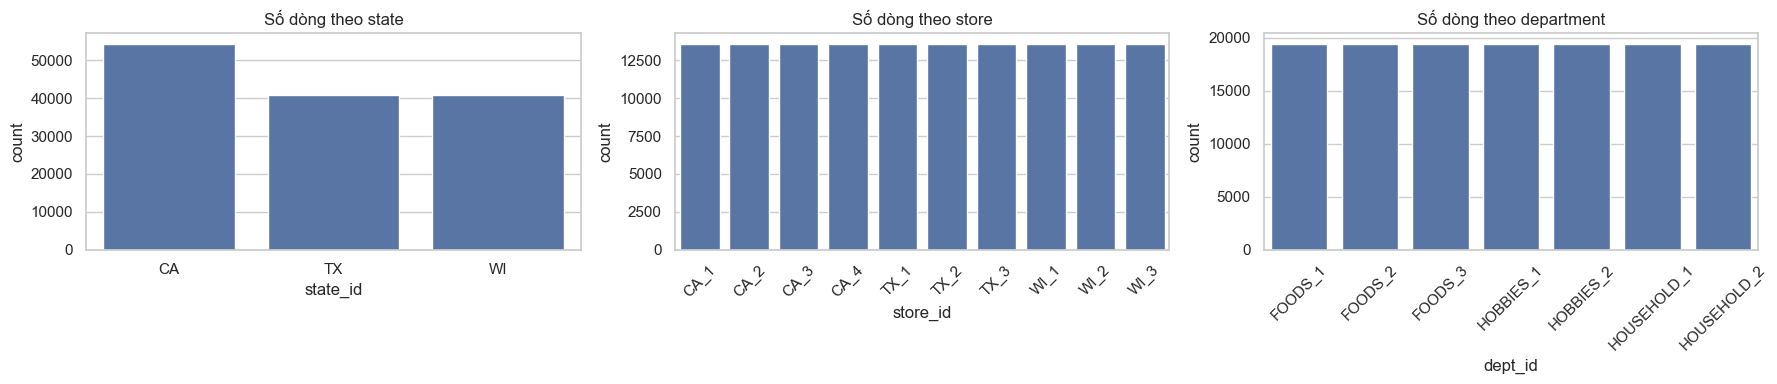

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.countplot(data=df, x="state_id", ax=axes[0])
axes[0].set_title("Số dòng theo state")

sns.countplot(data=df, x="store_id", ax=axes[1])
axes[1].set_title("Số dòng theo store")
axes[1].tick_params(axis="x", rotation=45)

sns.countplot(data=df, x="dept_id", ax=axes[2])
axes[2].set_title("Số dòng theo department")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Nhận xét: Qua biểu đồ cho thấy là dữ liệu department theo store của mỗi state trong scope thời gian đầy đủ không thiếu ngày nào

#### 6.2. Tổng doanh thu theo department

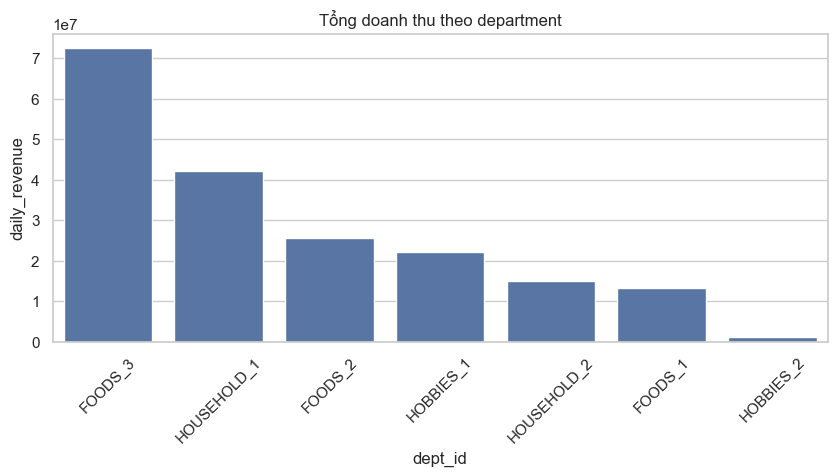

In [73]:
revenue_by_dept = (
    df.groupby("dept_id")["daily_revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 4))
sns.barplot(data=revenue_by_dept, x="dept_id", y="daily_revenue")
plt.title("Tổng doanh thu theo department")
plt.xticks(rotation=45)
plt.show()

#### 6.3. Phân phối của doanh thu của từng store-department

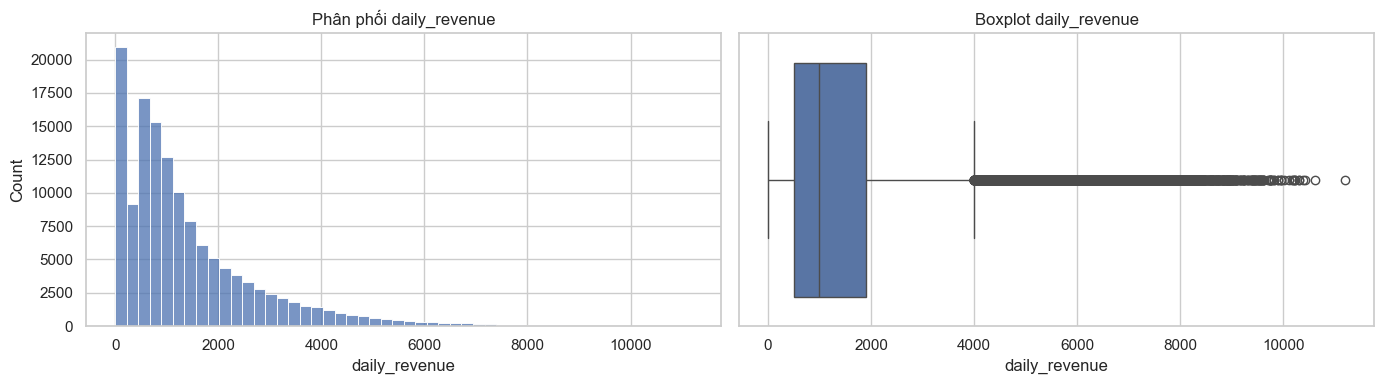

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["daily_revenue"], bins=50, ax=axes[0])
axes[0].set_title("Phân phối daily_revenue")

sns.boxplot(data=df, x="daily_revenue", ax=axes[1])
axes[1].set_title("Boxplot daily_revenue")

plt.tight_layout()
plt.show()

Nhận xét:
- Phân phối bị lệch phải mạnh
- Phần lớn store-department-day có doanh thu thấp đến trung bình
- Có nhiều điểm doanh thu cao ở phần đuôi phải
- Boxplot đánh dấu nhiều outlier, nhưng trong retail đây chưa chắc là lỗi, có thể là ngày bán mạnh, store lớn, department lớn, weekend/event/seasonality

#### 6.4. Phân phối doanh thu theo từng department riêng

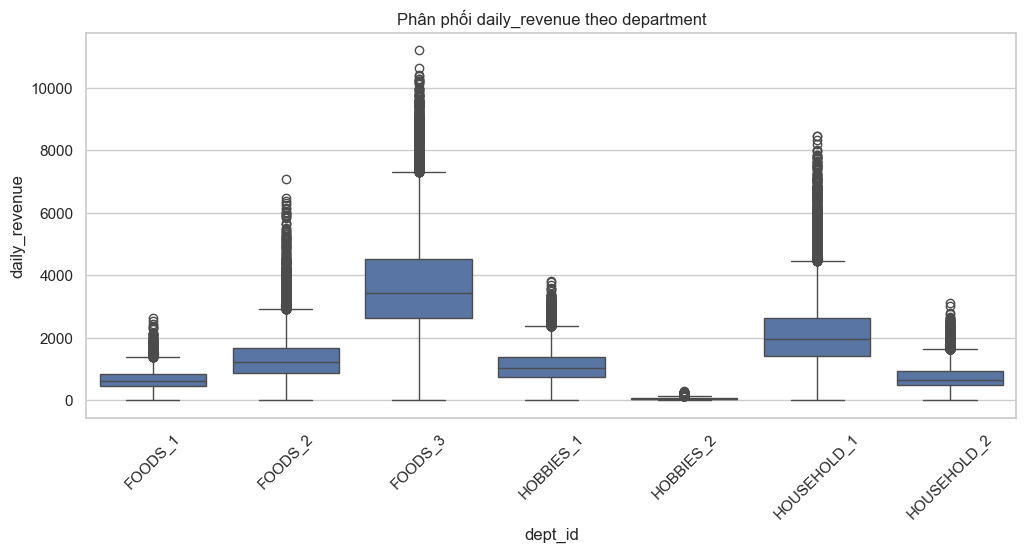

In [75]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="dept_id", y="daily_revenue")
plt.title("Phân phối daily_revenue theo department")
plt.xticks(rotation=45)
plt.show()

#### 6.5. Phân phối doanh thu theo từng store

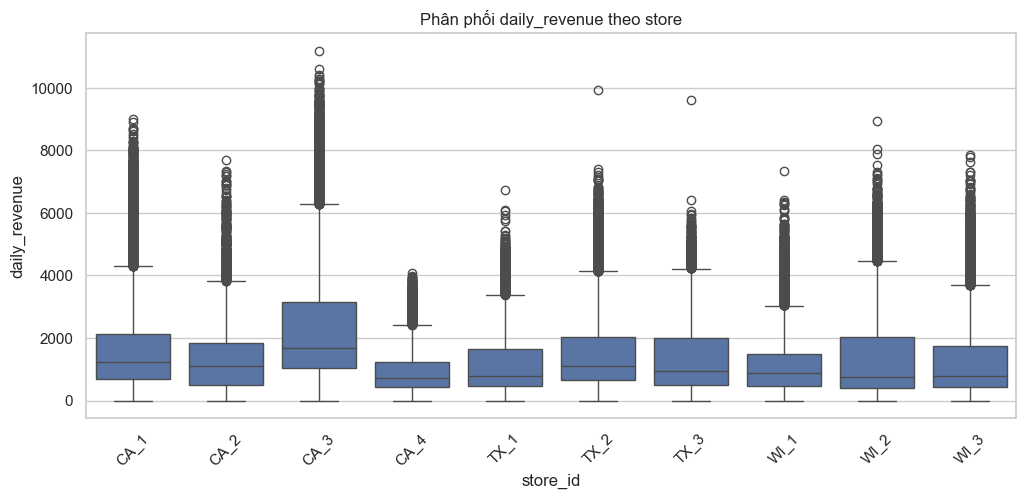

In [76]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="store_id", y="daily_revenue")
plt.title("Phân phối daily_revenue theo store")
plt.xticks(rotation=45)
plt.show()

#### 6.6. Biểu đồ thể hiện những sản phẩm mà có ngày không bán được

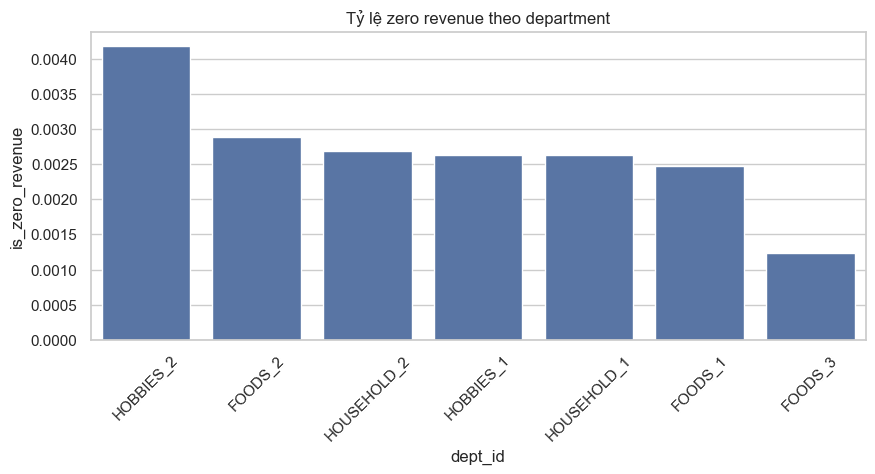

In [77]:
zero_rate_by_dept = (
    df.assign(is_zero_revenue=(df["daily_revenue"] == 0))
    .groupby("dept_id")["is_zero_revenue"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 4))
sns.barplot(data=zero_rate_by_dept, x="dept_id", y="is_zero_revenue")
plt.title("Tỷ lệ zero revenue theo department")
plt.xticks(rotation=45)
plt.show()

#### 6.7. Biểu đồ phân phối các biến weather

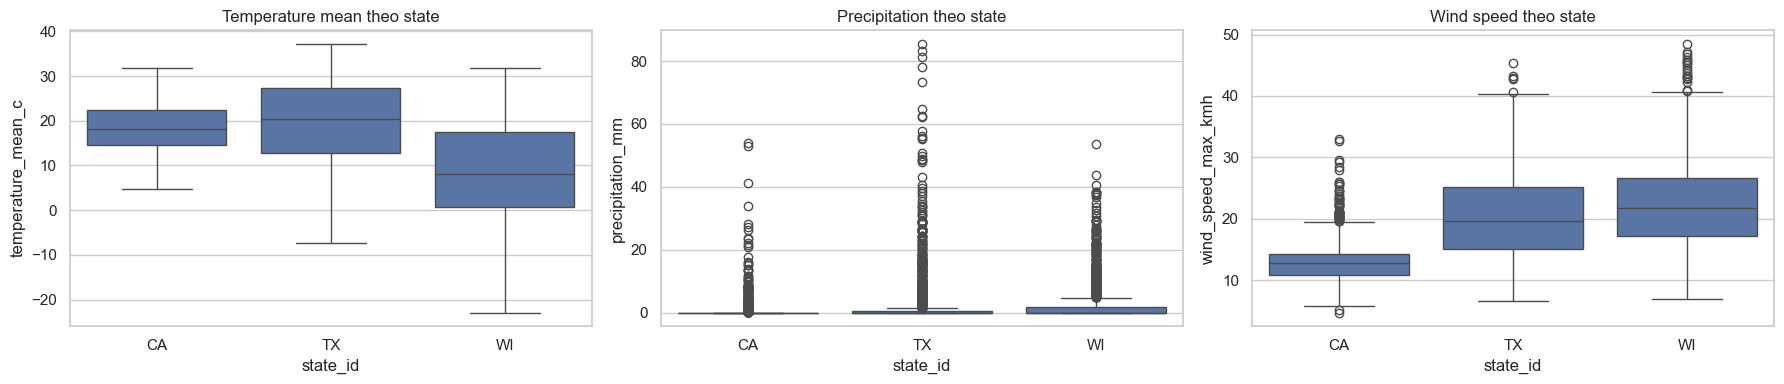

In [78]:
weather_daily = df[["date", "state_id", "temperature_mean_c", "precipitation_mm", "wind_speed_max_kmh"]].drop_duplicates()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.boxplot(data=weather_daily, x="state_id", y="temperature_mean_c", ax=axes[0])
axes[0].set_title("Temperature mean theo state")

sns.boxplot(data=weather_daily, x="state_id", y="precipitation_mm", ax=axes[1])
axes[1].set_title("Precipitation theo state")

sns.boxplot(data=weather_daily, x="state_id", y="wind_speed_max_kmh", ax=axes[2])
axes[2].set_title("Wind speed theo state")

plt.tight_layout()
plt.show()

Nhận xét

**1. Nhiệt độ:**

- TX nóng nhất.
- CA ở mức trung bình và ổn định hơn.
- WI lạnh nhất và biến động mạnh nhất.  
  WI có khoảng nhiệt rộng, xuống dưới 0°C khá nhiều. Điều này hợp lý vì WI ở vùng lạnh hơn.
- TX có median nhiệt độ cao hơn CA và WI.

**2. Lượng mưa:**

Ở cả 3 bang, phần lớn ngày có precipitation rất thấp hoặc bằng 0. Tuy nhiên, vẫn có nhiều outlier mưa lớn.

- TX có các ngày precipitation rất cao.
- WI cũng có nhiều ngày mưa đáng kể.
- CA ít mưa hơn và ít có ngày mưa lớn hơn.

Biến precipitation bị lệch phải mạnh, tức là phân phối rất skewed. Khi đưa vào model, có thể nên tạo thêm biến dạng binary như:

- `is_rain_day`
- `heavy_rain_day`

**3. Gió:**

- CA có wind speed thấp và ổn định hơn.
- TX và WI có wind speed cao hơn.
- WI có nhiều outlier gió mạnh nhất.

=> Nhìn chung, weather không phân bố giống nhau giữa các state.

### 7. Kiểm tra event và SNAP distribution

In [79]:
event_summary = pd.DataFrame({
    "column": ["event_name_1", "event_type_1", "event_name_2", "event_type_2", "event_count"],
    "unique_values": [
        df["event_name_1"].nunique(dropna=True),
        df["event_type_1"].nunique(dropna=True),
        df["event_name_2"].nunique(dropna=True),
        df["event_type_2"].nunique(dropna=True),
        df["event_count"].nunique(dropna=True),
    ],
    "missing_rate": [
        df["event_name_1"].isna().mean(),
        df["event_type_1"].isna().mean(),
        df["event_name_2"].isna().mean(),
        df["event_type_2"].isna().mean(),
        df["event_count"].isna().mean(),
    ]
})

display(event_summary)

display(df["event_type_1"].value_counts(dropna=False))
display(df["event_count"].value_counts(dropna=False))

,column,unique_values,missing_rate
0,event_name_1,30,0.9186
1,event_type_1,4,0.9186
2,event_name_2,4,0.9979
3,event_type_2,2,0.9979
4,event_count,3,0.0000


event_type_1
NaN          124810
Religious      3780
National       3570
Cultural       2590
Sporting       1120
Name: count, dtype: int64

event_count
0    124810
1     10780
2       280
Name: count, dtype: int64

In [80]:
snap_cols = ["snap_CA", "snap_TX", "snap_WI", "snap_active"]

for col in snap_cols:
    print(col)
    display(df[col].value_counts(normalize=True).rename("rate"))

snap_CA


snap_CA
0   0.6703
1   0.3297
Name: rate, dtype: float64

snap_TX


snap_TX
0   0.6703
1   0.3297
Name: rate, dtype: float64

snap_WI


snap_WI
0   0.6703
1   0.3297
Name: rate, dtype: float64

snap_active


snap_active
0   0.6703
1   0.3297
Name: rate, dtype: float64

#### 8. Clean feature

In [81]:
key_cols = [
    "date",
    "store_id",
    "dept_id"
]

raw_reference_cols = [
    "d",
    "wm_yr_wk"
]

target_cols = [
    "daily_revenue"
]

hierarchy_cols = [
    "state_id",
    "cat_id",
    "dept_id",
    "store_id"
]

time_cols = [
    "year",
    "month",
    "quarter",
    "week_of_year",
    "day_of_month",
    "day_of_year",
    "day_of_week",
    "day_of_week_num",
    "is_weekend",
    "year_month"
]

drop_time_duplicate_cols = [
    "weekday",
    "wday"
]


event_cols = [
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2",
    "event_count"
]

df["has_event"] = (df["event_count"] > 0).astype(int)

snap_cols = [
    "snap_active"
]

snap_raw_cols = [
    "snap_CA",
    "snap_TX",
    "snap_WI"
]

weather_cols = [
    "weather_code",
    "temperature_max_c",
    "temperature_min_c",
    "temperature_mean_c",
    "apparent_temperature_mean_c",
    "precipitation_mm",
    "rain_mm",
    "snowfall_cm",
    "wind_speed_max_kmh",
    "wind_gusts_max_kmh",
    "shortwave_radiation_mj_m2"
]

weather_metadata_cols = [
    "weather_location_id",
    "location_name",
    "weather_spatial_level",
    "latitude_requested",
    "longitude_requested",
    "latitude_open_meteo",
    "longitude_open_meteo",
    "elevation_m",
    "timezone",
    "utc_offset_seconds",
    "weather_source"
]

leakage_risk_cols = [
    "daily_units",
    "active_item_count",
    "has_sales",
    "weighted_avg_sell_price"
]

### 9. EDA

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Tạo bảng EDA gọn, giữ df gốc để trace khi cần.
key_cols = ["date", "store_id", "state_id", "cat_id", "dept_id"]
target_cols = ["daily_revenue"]
time_cols = [
    "year", "month", "quarter", "week_of_year",
    "day_of_month", "day_of_year", "day_of_week",
    "day_of_week_num", "is_weekend", "year_month"
]
event_cols_clean = ["event_name_1", "event_type_1", "event_name_2", "event_type_2", "event_count"]
snap_cols_clean = ["snap_active"]
weather_cols_clean = [
    "weather_code", "temperature_max_c", "temperature_min_c", "temperature_mean_c",
    "apparent_temperature_mean_c", "precipitation_mm", "rain_mm", "snowfall_cm",
    "wind_speed_max_kmh", "wind_gusts_max_kmh", "shortwave_radiation_mj_m2"
]
leakage_risk_cols = ["daily_units", "active_item_count", "has_sales", "weighted_avg_sell_price"]

eda_cols = key_cols + target_cols + time_cols + event_cols_clean + snap_cols_clean + weather_cols_clean + leakage_risk_cols
eda_cols = list(dict.fromkeys(eda_cols))

df_eda = df[eda_cols].copy()
df_eda["date"] = pd.to_datetime(df_eda["date"])
df_eda = df_eda.sort_values("date").copy()

# Feature phụ trợ cho EDA. Các cột derived từ same-day sales không dùng trực tiếp cho forecasting model.
df_eda["has_event"] = (df_eda["event_count"] > 0).astype(int)
df_eda["is_rainy_day"] = (df_eda["precipitation_mm"] > 0).astype(int)
df_eda["is_snowy_day"] = (df_eda["snowfall_cm"] > 0).astype(int)
df_eda["log_daily_revenue"] = np.log1p(df_eda["daily_revenue"])
df_eda["revenue_per_unit"] = np.where(
    df_eda["daily_units"] > 0,
    df_eda["daily_revenue"] / df_eda["daily_units"],
    np.nan
)

print("df gốc:", df.shape)
print("df_eda:", df_eda.shape)
display(df_eda.head())

df gốc: (135870, 58)
df_eda: (135870, 42)


,date,store_id,state_id,cat_id,dept_id,daily_revenue,year,month,quarter,week_of_year,day_of_month,day_of_year,day_of_week,day_of_week_num,is_weekend,year_month,event_name_1,event_type_1,event_name_2,event_type_2,event_count,snap_active,weather_code,temperature_max_c,temperature_min_c,temperature_mean_c,apparent_temperature_mean_c,precipitation_mm,rain_mm,snowfall_cm,wind_speed_max_kmh,wind_gusts_max_kmh,shortwave_radiation_mj_m2,daily_units,active_item_count,has_sales,weighted_avg_sell_price,has_event,is_rainy_day,is_snowy_day,log_daily_revenue,revenue_per_unit
0,2011-01-29,CA_1,CA,FOODS,FOODS_1,681.1800,2011,1,1,4,29,29,Saturday,5,1,2011-01,NaN,NaN,NaN,NaN,0,0,3,18.1000,6.1000,11.7000,9.7000,0.0000,0.0000,0.0000,10.9000,25.9000,14.8100,297,70,1,2.2935,0,0,0,6.5253,2.2935
50,2011-01-29,WI_1,WI,FOODS,FOODS_2,293.4300,2011,1,1,4,29,29,Saturday,5,1,2011-01,NaN,NaN,NaN,NaN,0,0,73,-1.2000,-3.6000,-2.1000,-6.5000,1.3000,0.0000,1.1900,17.7000,34.2000,6.3400,108,20,1,2.7169,0,1,1,5.6850,2.7169
49,2011-01-29,WI_1,WI,FOODS,FOODS_1,809.1800,2011,1,1,4,29,29,Saturday,5,1,2011-01,NaN,NaN,NaN,NaN,0,0,73,-1.2000,-3.6000,-2.1000,-6.5000,1.3000,0.0000,1.1900,17.7000,34.2000,6.3400,343,76,1,2.3591,0,1,1,6.6973,2.3591
48,2011-01-29,TX_3,TX,HOUSEHOLD,HOUSEHOLD_2,616.7300,2011,1,1,4,29,29,Saturday,5,1,2011-01,NaN,NaN,NaN,NaN,0,0,1,22.6000,6.8000,14.3000,11.2000,0.0000,0.0000,0.0000,21.6000,38.5000,15.1600,120,83,1,5.1394,0,0,0,6.4261,5.1394
47,2011-01-29,TX_3,TX,HOUSEHOLD,HOUSEHOLD_1,"1,449.1799",2011,1,1,4,29,29,Saturday,5,1,2011-01,NaN,NaN,NaN,NaN,0,0,1,22.6000,6.8000,14.3000,11.2000,0.0000,0.0000,0.0000,21.6000,38.5000,15.1600,383,107,1,3.7838,0,0,0,7.2794,3.7838


#### 9.1. EDA target: phân phối `daily_revenue`

Câu hỏi: target có phân phối ổn định không, có skew/outlier không, và có cần biến đổi target cho modeling không?

,metric,value
0,mean,"1,410.0062"
1,median,985.7900
2,std,"1,384.2343"
3,min,0.0000
4,q1,500.7100
5,q3,"1,900.5075"
6,max,"11,198.9500"
7,skew,1.8467


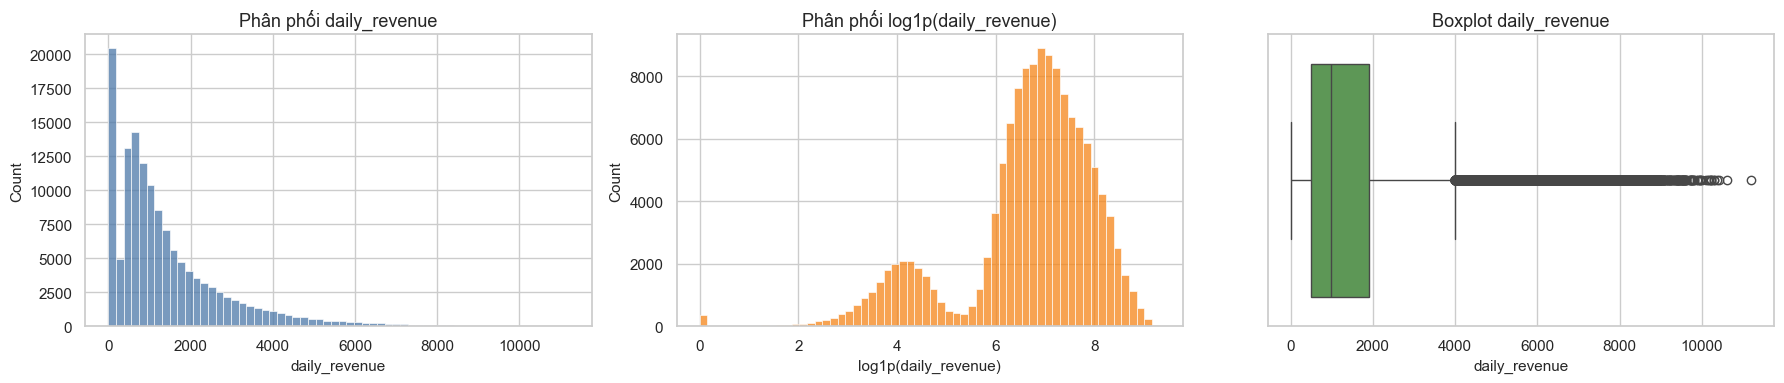

In [83]:
target_summary = pd.DataFrame({
    "metric": ["mean", "median", "std", "min", "q1", "q3", "max", "skew"],
    "value": [
        df_eda["daily_revenue"].mean(),
        df_eda["daily_revenue"].median(),
        df_eda["daily_revenue"].std(),
        df_eda["daily_revenue"].min(),
        df_eda["daily_revenue"].quantile(0.25),
        df_eda["daily_revenue"].quantile(0.75),
        df_eda["daily_revenue"].max(),
        df_eda["daily_revenue"].skew(),
    ]
})

display(target_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(df_eda["daily_revenue"], bins=60, color="#4C78A8", ax=axes[0])
axes[0].set_title("Phân phối daily_revenue")
axes[0].set_xlabel("daily_revenue")

sns.histplot(df_eda["log_daily_revenue"], bins=60, color="#F58518", ax=axes[1])
axes[1].set_title("Phân phối log1p(daily_revenue)")
axes[1].set_xlabel("log1p(daily_revenue)")

sns.boxplot(data=df_eda, x="daily_revenue", color="#54A24B", ax=axes[2])
axes[2].set_title("Boxplot daily_revenue")
axes[2].set_xlabel("daily_revenue")

plt.tight_layout()
plt.show()

**Insight:** `daily_revenue` lệch phải mạnh: mean khoảng `1,410`, median khoảng `986`, max khoảng `11,199`, skew khoảng `1.85`.

**Evidence:** Histogram có đuôi phải dài; boxplot có nhiều điểm doanh thu cao; bảng summary cho thấy mean lớn hơn median rõ rệt.

**Ý nghĩa Data Science:** Không nên giả định target phân phối chuẩn. Nếu dùng model tối ưu MSE/RMSE, các ngày revenue rất cao có thể chi phối loss.

**Feature engineering gợi ý:** tạo `log_daily_revenue = log1p(daily_revenue)` cho model thử nghiệm; tạo lag/rolling revenue theo store-dept.

**Kiểm định/ablation:** so sánh baseline dùng target gốc và target log-transform; đánh giá lỗi riêng theo department/store để xem nhóm doanh thu lớn có dominate model không.

**Limitation:** outlier không tự động là lỗi dữ liệu; trong retail, outlier có thể là peak sales thật.

#### 9.2. EDA theo thời gian: trend và seasonality dài hạn

Câu hỏi: tổng doanh thu có xu hướng theo thời gian không, và có những ngày peak đáng chú ý không?

,year,daily_revenue
0,2011,"23,891,336.0950"
1,2012,"32,649,200.8746"
2,2013,"35,923,373.3411"
3,2014,"37,861,913.2164"
4,2015,"42,416,456.5945"
5,2016,"18,835,265.9931"


,date,daily_revenue,revenue_rolling_28,revenue_rolling_90,year
1933,2016-05-15,"191,941.7296","137,372.5663","133,477.0231",2016
1863,2016-03-06,"181,445.5699","132,959.6195","124,326.2850",2016
1891,2016-04-03,"180,822.4400","129,878.8260","128,879.3316",2016
1897,2016-04-09,"177,632.3298","131,349.2357","129,404.1128",2016
1940,2016-05-22,"175,297.4199","139,320.5720","134,052.5384",2016
1834,2016-02-06,"174,438.6998","124,191.6281","118,914.3771",2016
1898,2016-04-10,"174,323.0698","131,769.1335","130,035.9236",2016
1932,2016-05-14,"171,719.7804","136,426.7184","132,973.9252",2016
1919,2016-05-01,"171,326.3500","133,859.7995","132,285.3176",2016
1925,2016-05-07,"170,625.5199","134,842.6299","132,702.7302",2016


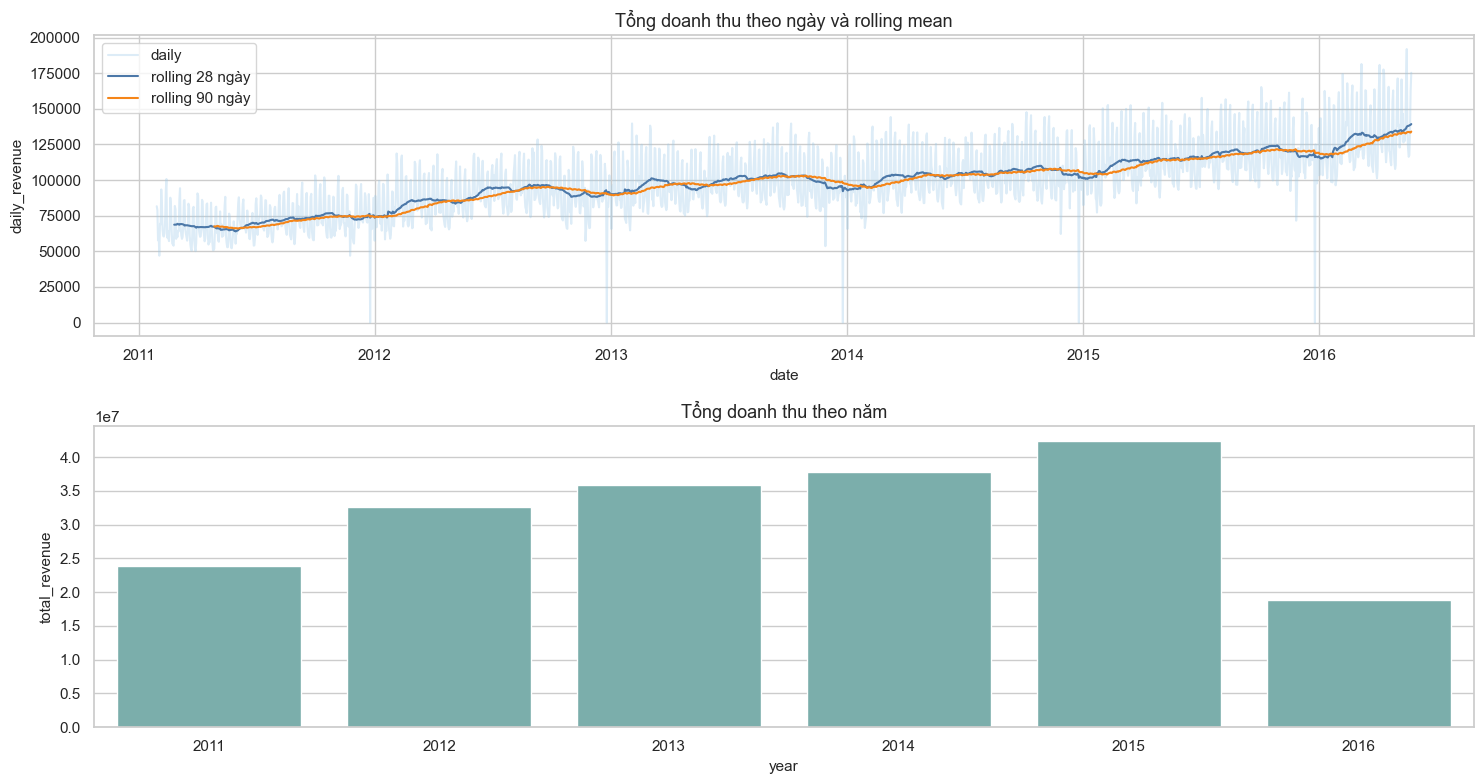

In [84]:
daily_total_revenue = (
    df_eda.groupby("date", as_index=False)["daily_revenue"]
    .sum()
    .sort_values("date")
)
daily_total_revenue["revenue_rolling_28"] = daily_total_revenue["daily_revenue"].rolling(28).mean()
daily_total_revenue["revenue_rolling_90"] = daily_total_revenue["daily_revenue"].rolling(90).mean()
daily_total_revenue["year"] = daily_total_revenue["date"].dt.year

yearly_revenue = (
    daily_total_revenue.groupby("year", as_index=False)["daily_revenue"]
    .sum()
)

display(yearly_revenue)
display(daily_total_revenue.sort_values("daily_revenue", ascending=False).head(10))

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=False)

sns.lineplot(data=daily_total_revenue, x="date", y="daily_revenue", color="#9ecae9", alpha=0.35, ax=axes[0], label="daily")
sns.lineplot(data=daily_total_revenue, x="date", y="revenue_rolling_28", color="#4C78A8", ax=axes[0], label="rolling 28 ngày")
sns.lineplot(data=daily_total_revenue, x="date", y="revenue_rolling_90", color="#F58518", ax=axes[0], label="rolling 90 ngày")
axes[0].set_title("Tổng doanh thu theo ngày và rolling mean")
axes[0].set_xlabel("date")
axes[0].set_ylabel("daily_revenue")
axes[0].legend()

sns.barplot(data=yearly_revenue, x="year", y="daily_revenue", color="#72B7B2", ax=axes[1])
axes[1].set_title("Tổng doanh thu theo năm")
axes[1].set_xlabel("year")
axes[1].set_ylabel("total_revenue")

plt.tight_layout()
plt.show()

**Insight:** Tổng doanh thu năm tăng từ 2011 đến 2015; năm 2016 thấp hơn vì dữ liệu chỉ tới `2016-05-22`, chưa đủ cả năm.

**Evidence:** Bảng yearly revenue cho thấy 2011 khoảng `23.9M`, 2015 khoảng `42.4M`; ngày có tổng doanh thu cao nhất là `2016-05-15` với khoảng `191,942`.

**Ý nghĩa Data Science:** Cần chia train/test theo thời gian, không shuffle. Trend dài hạn và seasonality có thể quan trọng cho forecasting.

**Feature engineering gợi ý:** `year`, `month`, `week_of_year`, `day_of_week`, lag 7/28 ngày, rolling mean 28/90 ngày.

**Kiểm định/ablation:** so sánh model chỉ dùng calendar với model thêm lag/rolling để đo giá trị của lịch sử doanh thu.

**Limitation:** tổng theo năm bị lệch nếu so sánh năm không đủ dữ liệu, đặc biệt 2016.

#### 9.3. EDA theo department: nhóm sản phẩm nào đóng góp nhiều nhất?

Câu hỏi: revenue có bị dominate bởi một vài department không?

,cat_id,dept_id,total_revenue,mean_revenue,median_revenue,row_count,revenue_share
2,FOODS,FOODS_3,"72,345,863.7778","3,727.2470","3,440.6800",19410,0.3776
5,HOUSEHOLD,HOUSEHOLD_1,"42,132,778.5504","2,170.6738","1,963.5200",19410,0.2199
1,FOODS,FOODS_2,"25,592,365.6414","1,318.5145","1,226.6250",19410,0.1336
3,HOBBIES,HOBBIES_1,"22,120,244.5109","1,139.6314","1,025.9850",19410,0.1155
6,HOUSEHOLD,HOUSEHOLD_2,"14,983,097.8670",771.9267,653.3250,19410,0.0782
0,FOODS,FOODS_1,"13,201,796.0601",680.1544,631.0450,19410,0.0689
4,HOBBIES,HOBBIES_2,"1,201,399.7070",61.8959,55.7650,19410,0.0063


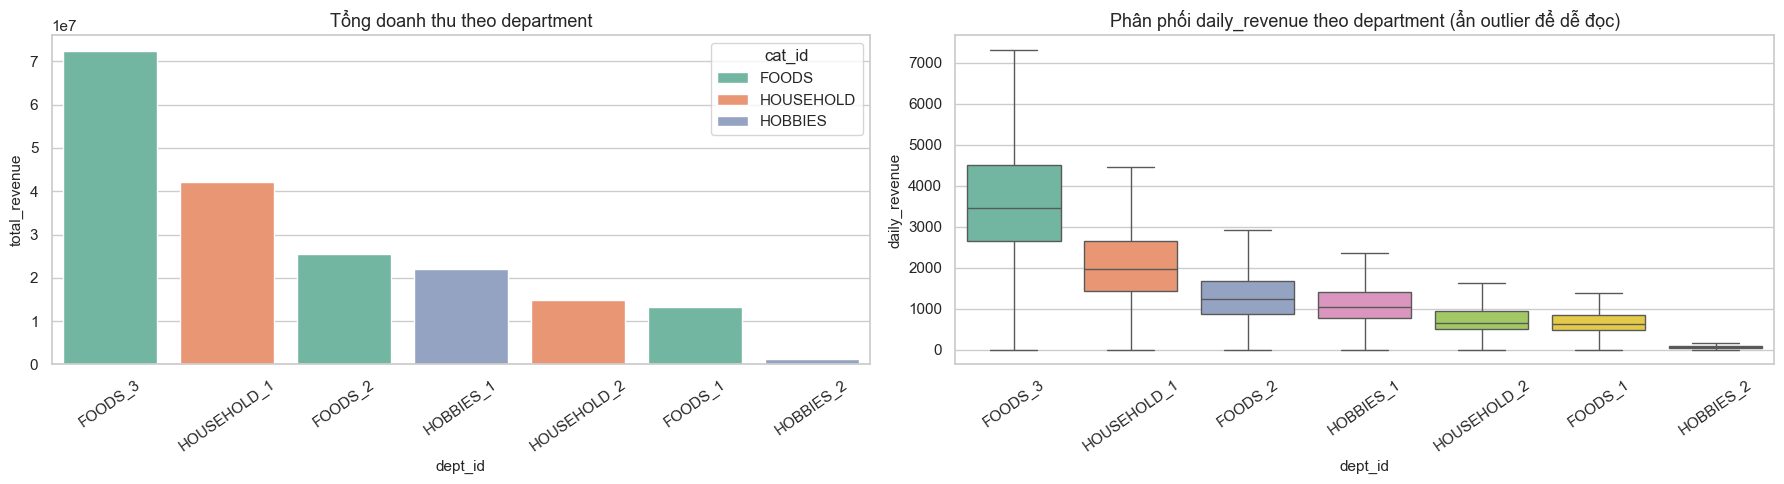

In [85]:
revenue_by_dept = (
    df_eda.groupby(["cat_id", "dept_id"], as_index=False)
    .agg(
        total_revenue=("daily_revenue", "sum"),
        mean_revenue=("daily_revenue", "mean"),
        median_revenue=("daily_revenue", "median"),
        row_count=("daily_revenue", "size")
    )
    .sort_values("total_revenue", ascending=False)
)
revenue_by_dept["revenue_share"] = revenue_by_dept["total_revenue"] / revenue_by_dept["total_revenue"].sum()
dept_order = revenue_by_dept["dept_id"].tolist()

display(revenue_by_dept)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.barplot(data=revenue_by_dept, x="dept_id", y="total_revenue", hue="cat_id", dodge=False, palette="Set2", ax=axes[0])
axes[0].set_title("Tổng doanh thu theo department")
axes[0].set_xlabel("dept_id")
axes[0].set_ylabel("total_revenue")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(title="cat_id")

sns.boxplot(data=df_eda, x="dept_id", y="daily_revenue", order=dept_order, palette="Set2", showfliers=False, ax=axes[1])
axes[1].set_title("Phân phối daily_revenue theo department (ẩn outlier để dễ đọc)")
axes[1].set_xlabel("dept_id")
axes[1].set_ylabel("daily_revenue")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

**Insight:** `FOODS_3` là department dominate revenue, chiếm khoảng `37.8%` tổng doanh thu. `HOUSEHOLD_1` đứng thứ hai khoảng `22.0%`. `HOBBIES_2` rất nhỏ, chỉ khoảng `0.6%`.

**Evidence:** Bar chart total revenue theo department và bảng `revenue_share`; boxplot cho thấy median của `FOODS_3` cao hơn hẳn các department khác.

**Ý nghĩa Data Science:** `dept_id` là feature rất quan trọng. Nếu model không biết department, baseline doanh thu sẽ bị trộn giữa các nhóm có quy mô khác nhau.

**Feature engineering gợi ý:** categorical encoding cho `dept_id`/`cat_id`; lag/rolling revenue riêng theo `store_id + dept_id`; historical mean theo department.

**Kiểm định/ablation:** so sánh model có `dept_id` với model không có `dept_id`; đánh giá lỗi theo từng department.

**Limitation:** `FOODS_3` cao hơn không có nghĩa department này “gây ra” doanh thu cao; nó có thể có nhiều item hơn hoặc nhu cầu nền lớn hơn.

Doanh thu hôm nay của một department trong một store thường sẽ liên quan đến doanh thu các ngày trước đó của chính store+department đó.

Historical mean theo department : department này thường có doanh thu trung bình bao nhiêu

#### 9.4. EDA theo store/state: cửa hàng và vị trí có khác nhau không?

Câu hỏi: store nào có doanh thu cao hơn, và pattern store-department có khác biệt không?

,state_id,store_id,total_revenue,mean_revenue,median_revenue
2,CA,CA_3,"32,699,137.6831","2,406.6488","1,692.8200"
0,CA,CA_1,"22,954,283.7756","1,689.4299","1,231.9300"
5,TX,TX_2,"20,893,002.1948","1,537.7200","1,092.2900"
6,TX,TX_3,"18,190,298.6966","1,338.8017",938.1500
8,WI,WI_2,"18,131,985.0430","1,334.5098",765.8500
1,CA,CA_2,"17,848,209.3906","1,313.6240","1,089.1200"
9,WI,WI_3,"17,250,126.1765","1,269.6052",779.9600
4,TX,TX_1,"16,037,341.1457","1,180.3445",795.7500
7,WI,WI_1,"15,107,433.8073","1,111.9036",877.0700
3,CA,CA_4,"12,465,728.2013",917.4747,711.1000


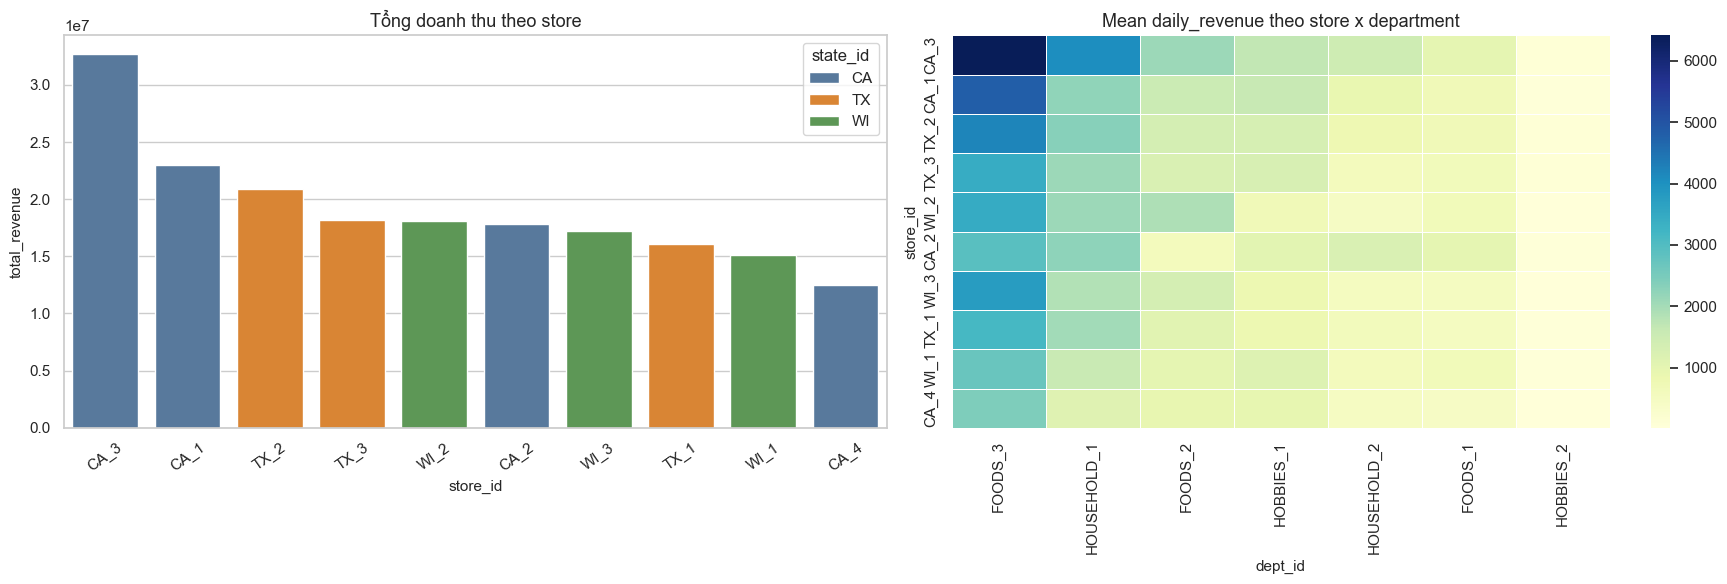

In [86]:
revenue_by_store = (
    df_eda.groupby(["state_id", "store_id"], as_index=False)
    .agg(
        total_revenue=("daily_revenue", "sum"),
        mean_revenue=("daily_revenue", "mean"),
        median_revenue=("daily_revenue", "median")
    )
    .sort_values("total_revenue", ascending=False)
)
store_order = revenue_by_store["store_id"].tolist()

store_dept_mean = (
    df_eda.groupby(["store_id", "dept_id"], as_index=False)["daily_revenue"]
    .mean()
    .pivot(index="store_id", columns="dept_id", values="daily_revenue")
    .loc[store_order, dept_order]
)

display(revenue_by_store)

def state_color(state):
    return {"CA": "#4C78A8", "TX": "#F58518", "WI": "#54A24B"}.get(state, "#999999")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=revenue_by_store, x="store_id", y="total_revenue", hue="state_id", dodge=False, palette={"CA":"#4C78A8", "TX":"#F58518", "WI":"#54A24B"}, ax=axes[0])
axes[0].set_title("Tổng doanh thu theo store")
axes[0].set_xlabel("store_id")
axes[0].set_ylabel("total_revenue")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(title="state_id")

sns.heatmap(store_dept_mean, cmap="YlGnBu", linewidths=0.4, linecolor="white", ax=axes[1])
axes[1].set_title("Mean daily_revenue theo store x department")
axes[1].set_xlabel("dept_id")
axes[1].set_ylabel("store_id")

plt.tight_layout()
plt.show()

**Insight:** `CA_3` là store có tổng và mean revenue cao nhất. Heatmap cho thấy tổ hợp `CA_3 + FOODS_3` nổi bật nhất, mean daily revenue khoảng `6,410`.

**Evidence:** Bảng `revenue_by_store` xếp `CA_3` đầu tiên; heatmap store x department có ô `CA_3/FOODS_3` đậm nhất.

**Ý nghĩa Data Science:** Có tương tác mạnh giữa store và department. Model chỉ dùng department hoặc chỉ dùng store sẽ mất một phần cấu trúc dữ liệu.

**Feature engineering gợi ý:** lag/rolling theo chuỗi `store_id + dept_id`; categorical encoding `store_id`; interaction feature hoặc target encoding cẩn thận theo train-only.

**Kiểm định/ablation:** so sánh model có `store_id`, có `dept_id`, và có cả hai; đánh giá lỗi theo store.

**Limitation:** Store cao hơn không có nghĩa địa điểm đó “tốt hơn” về nhân quả; có thể do quy mô, layout, item mix hoặc demand nền khác nhau.

#### 9.5. EDA seasonality: tháng, weekday/weekend

Câu hỏi: doanh thu có pattern theo lịch không?

,month,mean_revenue,median_revenue
1,2,"1,431.4043","1,009.7950"
7,8,"1,430.0691",986.2000
3,4,"1,429.8650",985.0100
2,3,"1,425.0377",993.2150
8,9,"1,424.4622",991.3550
9,10,"1,424.2631",981.7400
4,5,"1,416.1829",983.0050
6,7,"1,397.1953",979.4650
0,1,"1,395.1496",984.6450
5,6,"1,387.3884",985.2800


,day_of_week,mean_revenue,median_revenue
0,Monday,"1,355.1652",942.1250
1,Tuesday,"1,242.3780",888.9250
2,Wednesday,"1,227.6076",888.0650
3,Thursday,"1,233.0309",890.5600
4,Friday,"1,395.2479","1,010.8800"
5,Saturday,"1,703.1374","1,213.3600"
6,Sunday,"1,711.3305","1,180.2400"


,is_weekend,mean_revenue,median_revenue,row_count
0,0,"1,290.6859",922.8850,96950
1,1,"1,707.2340","1,196.5549",38920


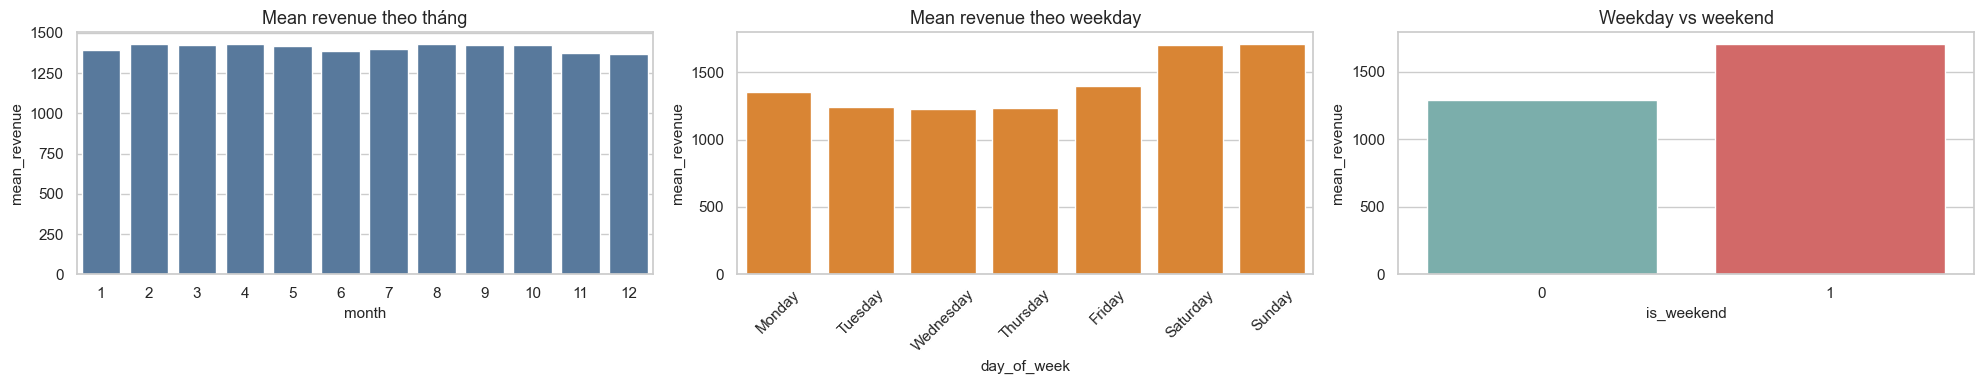

In [87]:
month_summary = (
    df_eda.groupby("month", as_index=False)
    .agg(mean_revenue=("daily_revenue", "mean"), median_revenue=("daily_revenue", "median"))
)
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_summary = (
    df_eda.groupby("day_of_week", as_index=False)
    .agg(mean_revenue=("daily_revenue", "mean"), median_revenue=("daily_revenue", "median"))
)
weekend_summary = (
    df_eda.groupby("is_weekend", as_index=False)
    .agg(mean_revenue=("daily_revenue", "mean"), median_revenue=("daily_revenue", "median"), row_count=("daily_revenue", "size"))
)

display(month_summary.sort_values("mean_revenue", ascending=False))
display(weekday_summary.set_index("day_of_week").loc[weekday_order].reset_index())
display(weekend_summary)

fig, axes = plt.subplots(1, 3, figsize=(20, 4))

sns.barplot(data=month_summary, x="month", y="mean_revenue", color="#4C78A8", ax=axes[0])
axes[0].set_title("Mean revenue theo tháng")
axes[0].set_xlabel("month")
axes[0].set_ylabel("mean_revenue")

sns.barplot(data=weekday_summary, x="day_of_week", y="mean_revenue", order=weekday_order, color="#F58518", ax=axes[1])
axes[1].set_title("Mean revenue theo weekday")
axes[1].set_xlabel("day_of_week")
axes[1].set_ylabel("mean_revenue")
axes[1].tick_params(axis="x", rotation=45)

sns.barplot(data=weekend_summary, x="is_weekend", y="mean_revenue", palette=["#72B7B2", "#E45756"], ax=axes[2])
axes[2].set_title("Weekday vs weekend")
axes[2].set_xlabel("is_weekend")
axes[2].set_ylabel("mean_revenue")

plt.tight_layout()
plt.show()

**Insight:** Weekend có mean revenue cao hơn weekday rõ rệt: khoảng `1,707` so với `1,291`, chênh khoảng `32%`. Sunday và Saturday là hai ngày cao nhất.

**Evidence:** Bảng `weekend_summary` và bar chart weekday/weekend; weekday chart xếp Sunday/Saturday cao nhất, Wednesday/Thursday thấp hơn.

**Ý nghĩa Data Science:** Calendar feature rất quan trọng cho forecasting. `is_weekend` và `day_of_week` nên là feature cơ bản trong model.

**Feature engineering gợi ý:** `is_weekend`, `day_of_week`, lag 7 ngày, rolling 7/28 ngày để bắt chu kỳ tuần.

**Kiểm định/ablation:** kiểm định khác biệt weekday vs weekend bằng bootstrap/Mann-Whitney; ablation model có/không có `day_of_week`.

**Limitation:** Đây là so sánh mô tả; weekend có thể đi cùng promotion, event hoặc hành vi store khác mà dữ liệu không ghi nhận đầy đủ.

#### 9.6. EDA event và SNAP

Câu hỏi: event day và SNAP active day có liên quan đến revenue không?

,has_event,mean_revenue,median_revenue,row_count
0,0,"1,414.8775",990.6700,124810
1,1,"1,355.0346",916.9150,11060


,snap_active,mean_revenue,median_revenue,row_count
0,0,"1,357.7685",962.3150,91070
1,1,"1,516.1957","1,043.9600",44800


,event_type_1,mean_revenue,median_revenue,row_count
3,Sporting,"1,440.0270",996.2450,1120
0,Cultural,"1,435.3638",999.2350,2590
2,Religious,"1,416.6783",998.0350,3780
4,NaN,"1,414.8775",990.6700,124810
1,National,"1,204.8225",738.4700,3570


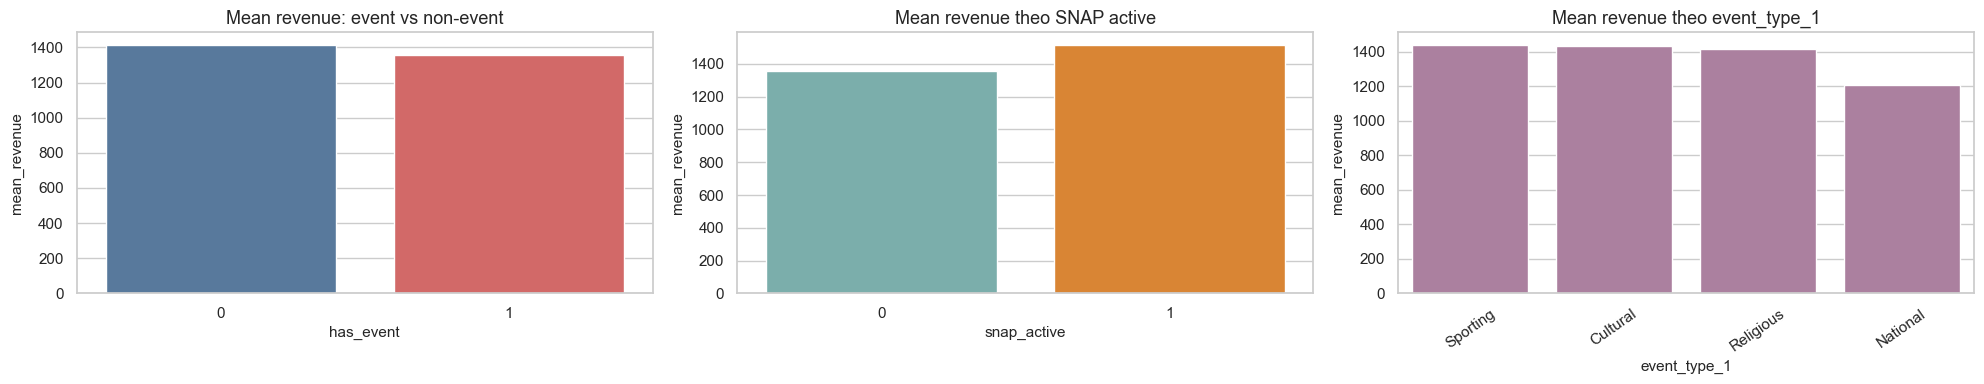

In [88]:
event_summary = (
    df_eda.groupby("has_event", as_index=False)
    .agg(mean_revenue=("daily_revenue", "mean"), median_revenue=("daily_revenue", "median"), row_count=("daily_revenue", "size"))
)
snap_summary = (
    df_eda.groupby("snap_active", as_index=False)
    .agg(mean_revenue=("daily_revenue", "mean"), median_revenue=("daily_revenue", "median"), row_count=("daily_revenue", "size"))
)
event_type_summary = (
    df_eda.groupby("event_type_1", dropna=False, as_index=False)
    .agg(mean_revenue=("daily_revenue", "mean"), median_revenue=("daily_revenue", "median"), row_count=("daily_revenue", "size"))
    .sort_values("mean_revenue", ascending=False)
)

display(event_summary)
display(snap_summary)
display(event_type_summary)

fig, axes = plt.subplots(1, 3, figsize=(20, 4))

sns.barplot(data=event_summary, x="has_event", y="mean_revenue", palette=["#4C78A8", "#E45756"], ax=axes[0])
axes[0].set_title("Mean revenue: event vs non-event")
axes[0].set_xlabel("has_event")
axes[0].set_ylabel("mean_revenue")

sns.barplot(data=snap_summary, x="snap_active", y="mean_revenue", palette=["#72B7B2", "#F58518"], ax=axes[1])
axes[1].set_title("Mean revenue theo SNAP active")
axes[1].set_xlabel("snap_active")
axes[1].set_ylabel("mean_revenue")

sns.barplot(data=event_type_summary, x="event_type_1", y="mean_revenue", color="#B279A2", ax=axes[2])
axes[2].set_title("Mean revenue theo event_type_1")
axes[2].set_xlabel("event_type_1")
axes[2].set_ylabel("mean_revenue")
axes[2].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

**Insight:** SNAP active days có mean revenue cao hơn non-SNAP days: khoảng `1,516` so với `1,358`. Event days lại có mean revenue thấp hơn nhẹ so với non-event days trong so sánh thô.

**Evidence:** Bảng `snap_summary` và `event_summary`; bar chart SNAP có cột `snap_active = 1` cao hơn. Event chart cho thấy `has_event = 1` thấp hơn `0`.

**Ý nghĩa Data Science:** SNAP có thể là feature hữu ích. Event cần phân tích cẩn thận theo loại event, department và thời điểm, vì so sánh thô có thể bị confounding. Tức là ngày có event doanh thu cao là do event hay do cuối tuần hay do nhiều yếu tố khác?

**Feature engineering gợi ý:** `snap_active`, `has_event`, `event_type_1`, `event_count`, lag trước/sau event nếu cần.

**Kiểm định/ablation:** kiểm định SNAP effect sau khi kiểm soát `state_id`, `store_id`, `dept_id`, `month`, `day_of_week`; ablation model có/không có event/SNAP.

**Limitation:** Không kết luận event làm giảm revenue; event day có thể rơi vào season/day-of-week đặc thù.

#### 9.7. EDA weather: temperature, rain, wind

Câu hỏi: weather có variation và có liên quan mô tả với revenue không?

,index,daily_revenue
0,daily_revenue,1.0000
1,temperature_mean_c,0.0369
2,precipitation_mm,-0.0188
3,wind_speed_max_kmh,-0.0677


,temperature_bin,mean_revenue,row_count
0,<0,"1,274.5819",9933
1,0-10,"1,309.6386",23492
2,10-20,"1,444.1951",53277
3,20-30,"1,464.7964",43050
4,>30,"1,332.0089",6118


,rain_level,mean_revenue,median_revenue,row_count
0,0 no rain,"1,438.5464","1,014.0500",94619
1,1 light,"1,353.8507",927.0800,28721
2,2 medium,"1,326.5446",908.8900,9548
3,3 heavy,"1,312.5173",901.2250,2982


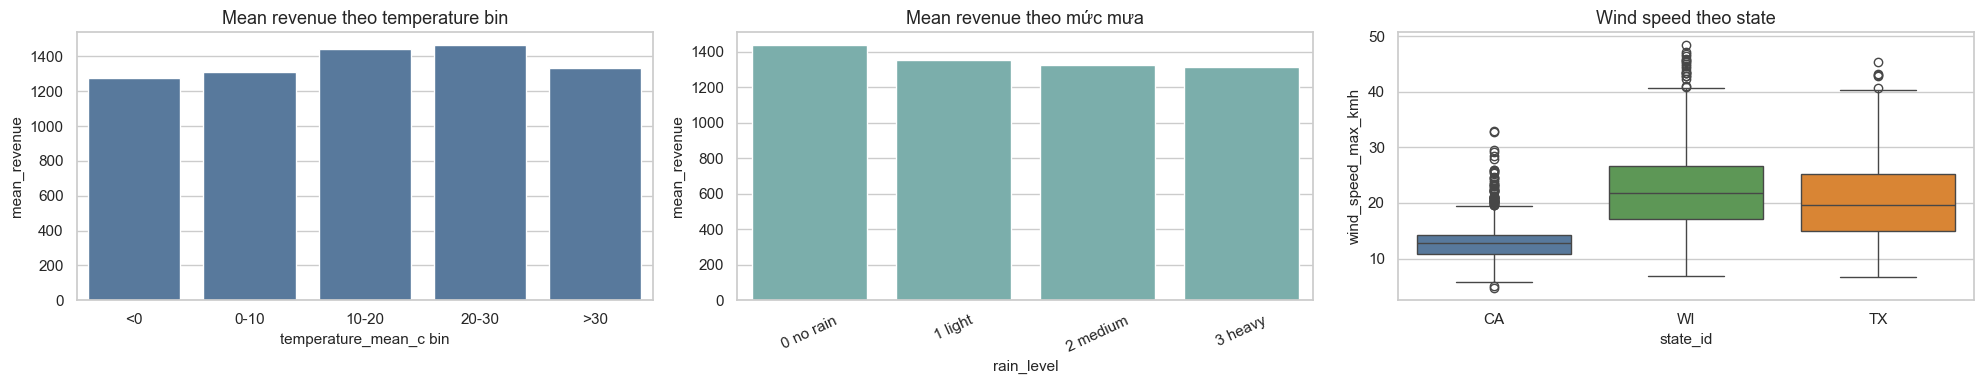

In [89]:
df_eda["temperature_bin"] = pd.cut(
    df_eda["temperature_mean_c"],
    bins=[-30, 0, 10, 20, 30, 50],
    labels=["<0", "0-10", "10-20", "20-30", ">30"]
)

df_eda["rain_level"] = "0 no rain"
df_eda.loc[(df_eda["precipitation_mm"] > 0) & (df_eda["precipitation_mm"] <= 5), "rain_level"] = "1 light"
df_eda.loc[(df_eda["precipitation_mm"] > 5) & (df_eda["precipitation_mm"] <= 20), "rain_level"] = "2 medium"
df_eda.loc[df_eda["precipitation_mm"] > 20, "rain_level"] = "3 heavy"

weather_corr = df_eda[["daily_revenue", "temperature_mean_c", "precipitation_mm", "wind_speed_max_kmh"]].corr()[["daily_revenue"]].reset_index()
temp_summary = df_eda.groupby("temperature_bin", observed=True, as_index=False).agg(mean_revenue=("daily_revenue", "mean"), row_count=("daily_revenue", "size"))
rain_summary = df_eda.groupby("rain_level", as_index=False).agg(mean_revenue=("daily_revenue", "mean"), median_revenue=("daily_revenue", "median"), row_count=("daily_revenue", "size"))
wind_state_summary = df_eda[["date", "state_id", "temperature_mean_c", "precipitation_mm", "wind_speed_max_kmh"]].drop_duplicates()

display(weather_corr)
display(temp_summary)
display(rain_summary)

fig, axes = plt.subplots(1, 3, figsize=(20, 4))

sns.barplot(data=temp_summary, x="temperature_bin", y="mean_revenue", color="#4C78A8", ax=axes[0])
axes[0].set_title("Mean revenue theo temperature bin")
axes[0].set_xlabel("temperature_mean_c bin")
axes[0].set_ylabel("mean_revenue")

sns.barplot(data=rain_summary, x="rain_level", y="mean_revenue", color="#72B7B2", ax=axes[1])
axes[1].set_title("Mean revenue theo mức mưa")
axes[1].set_xlabel("rain_level")
axes[1].set_ylabel("mean_revenue")
axes[1].tick_params(axis="x", rotation=25)

sns.boxplot(data=wind_state_summary, x="state_id", y="wind_speed_max_kmh", palette={"CA":"#4C78A8", "TX":"#F58518", "WI":"#54A24B"}, ax=axes[2])
axes[2].set_title("Wind speed theo state")
axes[2].set_xlabel("state_id")
axes[2].set_ylabel("wind_speed_max_kmh")

plt.tight_layout()
plt.show()

**Insight:** Tương quan tuyến tính thô giữa weather và revenue khá yếu: temperature khoảng `0.037`, precipitation khoảng `-0.019`, wind khoảng `-0.068`. Rainy days có mean revenue thấp hơn no-rain days trong so sánh thô.

**Evidence:** Bảng correlation và `rain_summary`; weather plot theo state cho thấy weather khác nhau rõ theo bang.

**Ý nghĩa Data Science:** Weather có thể là feature bổ sung, nhưng khả năng ảnh hưởng đơn giản/độc lập không mạnh bằng store, department và calendar. Weather cũng bị confound với `state_id`.

**Feature engineering gợi ý:** `is_rainy_day`, `rain_level`, `temperature_bin`, interaction `weather x dept_id` hoặc `weather x state_id`.

**Kiểm định/ablation:** đo weather bằng regression hoặc model ablation sau khi đã có `store_id`, `dept_id`, `month`, `day_of_week`, `snap_active`.

**Limitation:** Weather là representative city theo state, không phải weather tại từng store; không diễn giải causal trực tiếp.

#### 9.8. EDA outlier revenue theo ngữ cảnh

Câu hỏi: outlier revenue tập trung ở đâu và có nên xóa không?

Upper bound: 4000.2037499999997
Số dòng outlier: 8194
Tỷ lệ outlier: 0.06030764701552955


,dept_id,outlier_share
0,FOODS_3,0.8352
1,HOUSEHOLD_1,0.1494
2,FOODS_2,0.0154


,store_id,outlier_share
0,CA_3,0.3423
1,CA_1,0.1781
2,TX_2,0.1325
3,WI_2,0.1032
4,WI_3,0.0843
5,TX_3,0.0563
6,CA_2,0.0359
7,WI_1,0.0347
8,TX_1,0.0326
9,CA_4,0.0001


,date,store_id,state_id,cat_id,dept_id,daily_revenue,daily_units,weighted_avg_sell_price,is_weekend,has_event,snap_active,temperature_mean_c,precipitation_mm
79466,2014-03-09,CA_3,CA,FOODS,FOODS_3,"11,198.9500",4864,2.3024,1,0,1,18.5000,0.0000
81426,2014-04-06,CA_3,CA,FOODS,FOODS_3,"10,622.9700",4721,2.2502,1,0,1,18.8000,0.0000
82336,2014-04-19,CA_3,CA,FOODS,FOODS_3,"10,421.9600",4527,2.3022,1,0,0,18.6000,0.0000
87586,2014-07-03,CA_3,CA,FOODS,FOODS_3,"10,376.0000",4826,2.1500,0,0,1,25.7000,0.0000
94096,2014-10-04,CA_3,CA,FOODS,FOODS_3,"10,296.4700",4296,2.3968,1,1,1,28.1000,0.0000
94166,2014-10-05,CA_3,CA,FOODS,FOODS_3,"10,295.3800",4456,2.3105,1,0,1,26.1000,0.0000
82406,2014-04-20,CA_3,CA,FOODS,FOODS_3,"10,227.1400",4365,2.3430,1,1,0,19.5000,0.0000
82896,2014-04-27,CA_3,CA,FOODS,FOODS_3,"10,216.7200",4438,2.3021,1,0,0,16.1000,0.0000
104946,2015-03-08,CA_3,CA,FOODS,FOODS_3,"10,215.8300",4211,2.4260,1,0,1,17.6000,0.0000
81916,2014-04-13,CA_3,CA,FOODS,FOODS_3,"10,188.2100",4355,2.3394,1,0,0,14.5000,0.0000


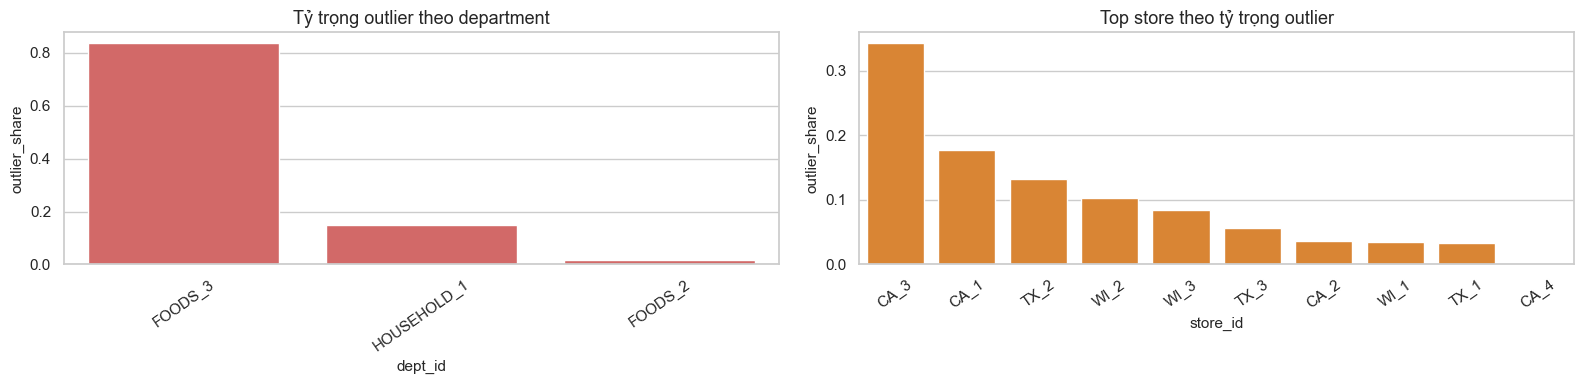

In [90]:
q1 = df_eda["daily_revenue"].quantile(0.25)
q3 = df_eda["daily_revenue"].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr

df_eda["is_revenue_outlier"] = (df_eda["daily_revenue"] > upper).astype(int)
outlier_revenue = df_eda[df_eda["is_revenue_outlier"] == 1].copy()

outlier_by_dept = (
    outlier_revenue["dept_id"].value_counts(normalize=True)
    .rename_axis("dept_id")
    .reset_index(name="outlier_share")
)
outlier_by_store = (
    outlier_revenue["store_id"].value_counts(normalize=True)
    .rename_axis("store_id")
    .reset_index(name="outlier_share")
)

print("Upper bound:", upper)
print("Số dòng outlier:", len(outlier_revenue))
print("Tỷ lệ outlier:", len(outlier_revenue) / len(df_eda))

display(outlier_by_dept)
display(outlier_by_store.head(10))
display(
    outlier_revenue[
        ["date", "store_id", "state_id", "cat_id", "dept_id", "daily_revenue", "daily_units", "weighted_avg_sell_price", "is_weekend", "has_event", "snap_active", "temperature_mean_c", "precipitation_mm"]
    ]
    .sort_values("daily_revenue", ascending=False)
    .head(20)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.barplot(data=outlier_by_dept, x="dept_id", y="outlier_share", color="#E45756", ax=axes[0])
axes[0].set_title("Tỷ trọng outlier theo department")
axes[0].set_xlabel("dept_id")
axes[0].set_ylabel("outlier_share")
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(data=outlier_by_store.head(10), x="store_id", y="outlier_share", color="#F58518", ax=axes[1])
axes[1].set_title("Top store theo tỷ trọng outlier")
axes[1].set_xlabel("store_id")
axes[1].set_ylabel("outlier_share")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

**Insight:** Outlier revenue chiếm khoảng `6.03%` dòng và tập trung mạnh ở `FOODS_3` khoảng `83.5%` trong nhóm outlier. Store `CA_3` chiếm khoảng `34.2%` outlier.

**Evidence:** Bảng `outlier_by_dept`, `outlier_by_store`, và top outlier rows; các dòng cao nhất chủ yếu là `CA_3 + FOODS_3`, thường rơi vào weekend/SNAP.

**Ý nghĩa Data Science:** Outlier là pattern có cấu trúc, không phải noise ngẫu nhiên. Xóa outlier sẽ làm mất thông tin về demand peak.

**Feature engineering gợi ý:** lag/rolling theo `store_id + dept_id`, `is_weekend`, `snap_active`, department/store encoding; có thể thử robust loss hoặc log target.

**Kiểm định/ablation:** đánh giá model theo nhóm outlier/non-outlier hoặc theo quantile revenue; so sánh RMSE và MAE.

**Limitation:** IQR toàn cục không công bằng cho mọi department vì mỗi department có quy mô doanh thu khác nhau; nếu cần, nên phát hiện outlier theo từng `dept_id` hoặc `store_id + dept_id`.

#### 9.9. Tổng kết EDA và hướng kiểm định tiếp theo

**Các insight đáng giữ lại:**

1. `daily_revenue` lệch phải mạnh, nên cân nhắc `log1p(daily_revenue)` và metric robust.
2. `dept_id` và `store_id` là hai chiều rất quan trọng; `FOODS_3` và `CA_3` nổi bật.
3. Weekend có doanh thu cao hơn weekday, nên calendar features cần có trong model.
4. SNAP có tín hiệu tăng revenue trong so sánh thô, nhưng cần kiểm soát state/store/dept/time.
5. Weather có tương quan thô yếu và bị confound với state; chỉ nên xem là feature bổ sung cần ablation.
6. Outlier revenue có cấu trúc rõ, không nên xóa tự động.

**Bước tiếp theo sau EDA:**

- Kiểm định/định lượng insight bằng group comparison hoặc regression mô tả.
- Tạo model-ready dataset với lag/rolling features.
- Loại các cột leakage khỏi model trực tiếp: `daily_units`, `active_item_count`, `has_sales`, `weighted_avg_sell_price`, `revenue_per_unit`.
- Làm ablation: baseline calendar/store/dept, sau đó thêm SNAP/event, sau đó thêm weather để đo giá trị tăng thêm.

### 10. Kiểm định thống kê

Ta kiểm định từng insight quan trọng thay vì gom tất cả vào một bảng. Với dữ liệu dạng panel time-series (`date + store_id + dept_id`), cách làm sẽ là:

- Quan sát lại bằng bảng/biểu đồ để xem tín hiệu có hợp lý không.
- Chọn kiểm định phù hợp với bản chất insight.
- Ưu tiên kiểm định theo block `store_id + dept_id` để giảm rủi ro p-value nhỏ giả tạo do quá nhiều dòng lặp theo thời gian.
- Đọc output ngay sau từng insight, rồi quyết định feature/modeling tiếp theo.

Các kiểm định bên dưới vẫn là kiểm định mô tả, không phải kết luận nhân quả.

#### 10.0. Chuẩn bị hàm kiểm định dùng chung

Ta dùng một vài helper nhỏ để tránh lặp code. Các helper này chỉ làm những việc đơn giản: tóm tắt hai nhóm, lấy chênh lệch mean theo block, bootstrap CI, paired t-test, Wilcoxon, sign test và effect size.

In [91]:
ALPHA = 0.05

# Bảng kiểm định riêng để không làm thay đổi df_eda gốc ở các phần trước.
df_test = df_eda.copy()
df_test["is_rainy_day"] = (df_test["precipitation_mm"] > 0).astype(int)
df_test["event_type_1_clean"] = df_test["event_type_1"].fillna("no_event")
df_test["store_dept"] = df_test["store_id"].astype(str) + "_" + df_test["dept_id"].astype(str)


def format_p_value(p_value):
    if pd.isna(p_value):
        return np.nan
    if p_value == 0:
        return "<1e-300"
    if p_value < 0.001:
        return f"{p_value:.2e}"
    return f"{p_value:.4f}"


def bootstrap_mean_ci(values, n_boot=5000, seed=42):
    values = pd.Series(values).dropna().to_numpy()
    rng = np.random.default_rng(seed)
    boot_means = rng.choice(values, size=(n_boot, len(values)), replace=True).mean(axis=1)
    return np.percentile(boot_means, [2.5, 97.5])


def binary_group_summary(data, flag_col, inactive_label="inactive", active_label="active"):
    summary = (
        data.groupby(flag_col)["daily_revenue"]
        .agg(row_count="size", mean_revenue="mean", median_revenue="median", std_revenue="std")
        .reset_index()
    )
    summary["group_label"] = summary[flag_col].map({0: inactive_label, 1: active_label})

    inactive = data.loc[data[flag_col] == 0, "daily_revenue"]
    active = data.loc[data[flag_col] == 1, "daily_revenue"]
    welch = stats.ttest_ind(active, inactive, equal_var=False)
    raw = pd.DataFrame({
        "method": ["raw row-level Welch t-test"],
        "mean_diff_active_minus_inactive": [active.mean() - inactive.mean()],
        "lift_pct": [(active.mean() / inactive.mean() - 1) * 100],
        "p_value": [welch.pvalue],
    })
    raw["p_value"] = raw["p_value"].map(format_p_value)
    return summary, raw


def binary_block_diff(data, flag_col, block_cols, active_value=1, inactive_value=0):
    pivot = (
        data.groupby(block_cols + [flag_col])["daily_revenue"]
        .mean()
        .unstack(flag_col)
    )
    pivot = pivot.dropna(subset=[inactive_value, active_value])
    return pivot[active_value] - pivot[inactive_value]


def blocked_binary_tests(data, flag_col, block_specs):
    rows = []
    for method_name, block_cols in block_specs:
        diff = binary_block_diff(data, flag_col, block_cols)
        ci_low, ci_high = bootstrap_mean_ci(diff)
        t_result = stats.ttest_1samp(diff, popmean=0)
        try:
            wilcoxon_p = stats.wilcoxon(diff).pvalue
        except ValueError:
            wilcoxon_p = np.nan
        sign_p = stats.binomtest(int((diff > 0).sum()), len(diff), 0.5).pvalue

        rows.append({
            "method": method_name,
            "n_blocks": len(diff),
            "mean_diff": diff.mean(),
            "median_diff": diff.median(),
            "ci_95_low": ci_low,
            "ci_95_high": ci_high,
            "cohen_dz": diff.mean() / diff.std(ddof=1),
            "positive_blocks": int((diff > 0).sum()),
            "negative_blocks": int((diff < 0).sum()),
            "paired_t_p": t_result.pvalue,
            "wilcoxon_p": wilcoxon_p,
            "sign_test_p": sign_p,
        })

    result = pd.DataFrame(rows)
    for col in ["mean_diff", "median_diff", "ci_95_low", "ci_95_high", "cohen_dz"]:
        result[col] = result[col].round(4)
    for col in ["paired_t_p", "wilcoxon_p", "sign_test_p"]:
        result[col] = result[col].map(format_p_value)
    return result


def group_effect_on_rows(data, group_col):
    tmp = data[[group_col, "daily_revenue"]].dropna().copy()
    groups = [g["daily_revenue"].to_numpy() for _, g in tmp.groupby(group_col)]
    anova = stats.f_oneway(*groups)
    kruskal = stats.kruskal(*groups)

    overall_mean = tmp["daily_revenue"].mean()
    group_stats = tmp.groupby(group_col)["daily_revenue"].agg(["mean", "size"])
    ss_between = ((group_stats["mean"] - overall_mean) ** 2 * group_stats["size"]).sum()
    ss_total = ((tmp["daily_revenue"] - overall_mean) ** 2).sum()
    level_mean = group_stats["mean"].sort_values(ascending=False)

    return {
        "group_col": group_col,
        "n_levels": tmp[group_col].nunique(),
        "eta_squared": ss_between / ss_total,
        "anova_p": anova.pvalue,
        "kruskal_p": kruskal.pvalue,
        "top_level": level_mean.index[0],
        "top_mean": level_mean.iloc[0],
        "bottom_level": level_mean.index[-1],
        "bottom_mean": level_mean.iloc[-1],
        "mean_range": level_mean.iloc[0] - level_mean.iloc[-1],
    }


def display_test_table(table):
    table = table.copy()
    for col in table.select_dtypes(include=["float", "float64"]).columns:
        if col not in ["anova_p", "kruskal_p", "p_value"]:
            table[col] = table[col].round(4)
    for col in ["anova_p", "kruskal_p", "p_value"]:
        if col in table.columns:
            table[col] = table[col].map(format_p_value)
    display(table)

#### 10.1. Insight: Weekend và weekday có pattern doanh thu khác nhau không?

**Chọn phương pháp:** Đây là calendar effect lặp lại trong mọi chuỗi `store_id + dept_id`, nên dùng:

- Biểu đồ mean theo `day_of_week` để quan sát seasonality tuần.
- Chênh lệch weekend - weekday theo từng chuỗi `store_id + dept_id`.
- Paired t-test, Wilcoxon và sign test trên 70 chênh lệch đó.
- Friedman test cho 7 weekday vì cùng một chuỗi được quan sát ở đủ các ngày trong tuần.

,day_of_week,mean_revenue,median_revenue,row_count
0,Monday,"1,355.1652",942.1250,19390
1,Tuesday,"1,242.3780",888.9250,19390
2,Wednesday,"1,227.6076",888.0650,19390
3,Thursday,"1,233.0309",890.5600,19390
4,Friday,"1,395.2479","1,010.8800",19390
5,Saturday,"1,703.1374","1,213.3600",19460
6,Sunday,"1,711.3305","1,180.2400",19460


,is_weekend,row_count,mean_revenue,median_revenue,std_revenue,group_label
0,0,96950,"1,290.6859",922.8850,"1,241.3356",weekday
1,1,38920,"1,707.2340","1,196.5549","1,651.3503",weekend


,method,mean_diff_active_minus_inactive,lift_pct,p_value
0,raw row-level Welch t-test,416.5480,32.2734,<1e-300


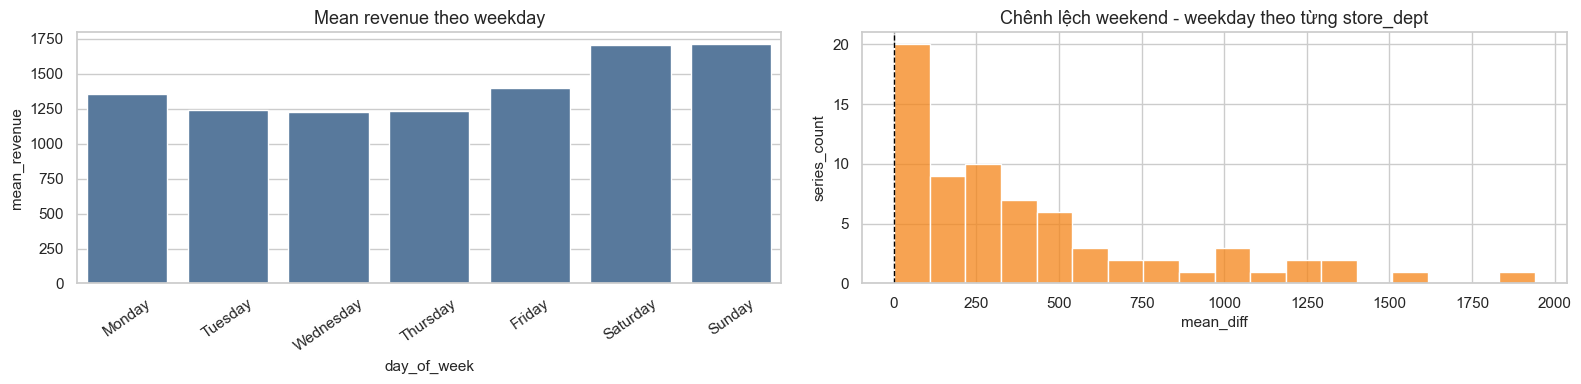

In [92]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekend_summary, weekend_raw_test = binary_group_summary(
    df_test,
    "is_weekend",
    inactive_label="weekday",
    active_label="weekend",
)
weekday_summary = (
    df_test.groupby("day_of_week", as_index=False)
    .agg(mean_revenue=("daily_revenue", "mean"), median_revenue=("daily_revenue", "median"), row_count=("daily_revenue", "size"))
    .set_index("day_of_week")
    .loc[weekday_order]
    .reset_index()
)
# tính doanh thu trung bình cuối tuần - doanh thu trung bình ngày thường
weekend_series_diff = binary_block_diff(df_test, "is_weekend", ["store_id", "dept_id"])

display(weekday_summary)
display(weekend_summary)
display(weekend_raw_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.barplot(data=weekday_summary, x="day_of_week", y="mean_revenue", color="#4C78A8", ax=axes[0])
axes[0].set_title("Mean revenue theo weekday")
axes[0].set_xlabel("day_of_week")
axes[0].set_ylabel("mean_revenue")
axes[0].tick_params(axis="x", rotation=35)

sns.histplot(weekend_series_diff, bins=18, color="#F58518", ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Chênh lệch weekend - weekday theo từng store_dept")
axes[1].set_xlabel("mean_diff")
axes[1].set_ylabel("series_count")

plt.tight_layout()
plt.show()

Biểu đồ bên phải chỉ nói tính trung bình toàn bộ dataset thì cuối tuần cao hơn.
Nhưng nó có thể có trường hợp chỉ CA3+FOODS_3 tăng rất mạnh cuối tuần còn các chuỗi khác không tăng.
Cuối tuần doanh thu cao hơn là do toàn bộ hệ thống đều vậy, hay chỉ do vài store/department lớn kéo trung bình lên?

Với mỗi chuỗi store_id + dept_id
Ta tính doanh thu trung bình chuỗi đó vào Saturday/Sunday - doanh thu trung bình chuỗi đó vào Monday-Friday
Sau đó lặp lại cho tất cả các chuỗi ta có
10 store x 7 depart = 70 series
Qua biểu đồ thấy 70/70 series đều có doanh thu cuối tuần cao hơn ngày thường

**Kết luận:** Weekend effect rất ổn định. Doanh thu cuối tuần cao hơn ngày thường ở tất cả 70 chuỗi store-department. Vì vậy is_weekend, day_of_week_num, và các lag theo chu kỳ 7 ngày như revenue_lag_7 là feature rất đáng giữ trong model forecasting.

trung bình, doanh thu cuối tuần cao hơn ngày thường khoảng 416,55
weekend cao hơn weekday khoảng 32,27% 

H0: mean revenue weekend = mean revenue weekday
H1: mean revenue weekend khác weekday

p-value cực nhỏ: bác bỏ H0: khác biệt mean giữ weekend và weekday là rất rõ trong dữ liệu, gần như không phải nhiễu ngẫu nhiên

In [93]:
# chứng minh: weekend cao hơn weekday một cách ổn định trên 70 store-dept
weekend_tests = blocked_binary_tests(
    df_test,
    "is_weekend",
    block_specs=[("paired by store_id + dept_id", ["store_id", "dept_id"])],
)

# chứng minh: doanh thu thay đổi có hệ thống theo 7 ngày trong tuần, không chỉ chia weekend/weekday
# đoạn này trả lời cho câu hỏi 7 ngày trong tuần có cùng mean revenue không?
# mỗi dòng = 1 storeid + deptid
# mỗi cột là từ Monday - Sunday
# giá trị = mean doanh thu của chuỗi đó vào ngày đó
# Giả thuyết của Friedman test:
# H0: revenue của Monday, Tuesday, ..., Sunday không khác nhau đáng kể
# H1: ít nhất một ngày có pattern khác các ngày còn lại

weekday_pivot = (
    df_test.groupby(["store_id", "dept_id", "day_of_week"])["daily_revenue"]
    .mean()
    .unstack("day_of_week")[weekday_order]
)
friedman = stats.friedmanchisquare(*[weekday_pivot[day] for day in weekday_order])
weekday_test = pd.DataFrame({
    "method": ["Friedman repeated-measures test across 7 weekdays"],
    "n_series": [len(weekday_pivot)],
    "statistic": [friedman.statistic],
    "p_value": [friedman.pvalue],
    "top_weekday": [weekday_summary.sort_values("mean_revenue", ascending=False).iloc[0]["day_of_week"]],
    "bottom_weekday": [weekday_summary.sort_values("mean_revenue", ascending=True).iloc[0]["day_of_week"]],
})
weekday_test["statistic"] = weekday_test["statistic"].round(4)
weekday_test["p_value"] = weekday_test["p_value"].map(format_p_value)

display(weekend_tests)
display(weekday_test)

,method,n_blocks,mean_diff,median_diff,ci_95_low,ci_95_high,cohen_dz,positive_blocks,negative_blocks,paired_t_p,wilcoxon_p,sign_test_p
0,paired by store_id + dept_id,70,416.5480,280.4042,317.4131,522.4180,0.9727,70,0,1.12e-11,3.56e-13,1.69e-21


,method,n_series,statistic,p_value,top_weekday,bottom_weekday
0,Friedman repeated-measures test across 7 weekdays,70,293.5408,1.98e-60,Sunday,Wednesday


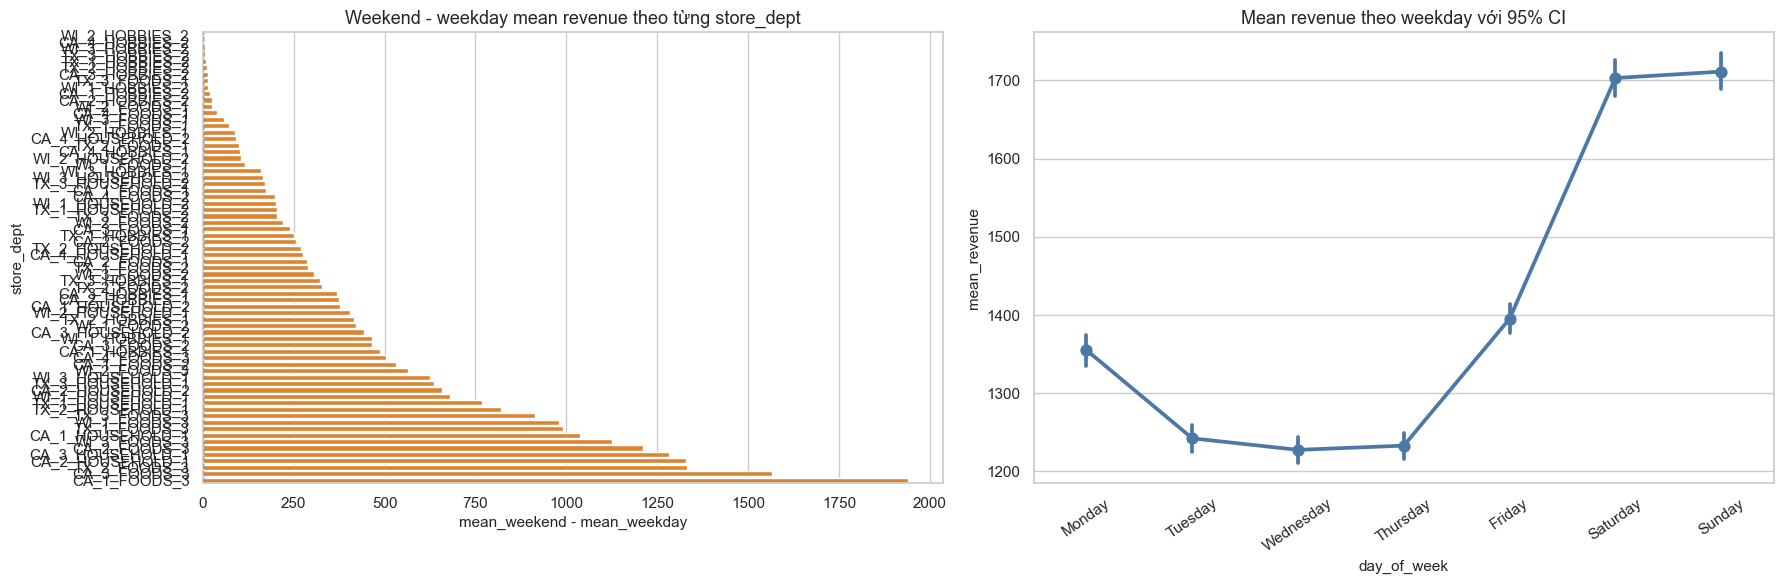

In [96]:
# Chuẩn bị dữ liệu chênh lệch weekend - weekday theo từng store_id + dept_id
weekend_diff_df = (
    df_test.groupby(["store_id", "dept_id", "is_weekend"])["daily_revenue"]
    .mean()
    .unstack("is_weekend")
    .rename(columns={0: "weekday_mean", 1: "weekend_mean"})
    .reset_index()
)

weekend_diff_df["store_dept"] = weekend_diff_df["store_id"] + "_" + weekend_diff_df["dept_id"]
weekend_diff_df["mean_diff"] = weekend_diff_df["weekend_mean"] - weekend_diff_df["weekday_mean"]
weekend_diff_df = weekend_diff_df.sort_values("mean_diff", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Biểu đồ 1: mỗi dòng là 1 store_dept, giá trị là weekend - weekday
sns.barplot(
    data=weekend_diff_df,
    y="store_dept",
    x="mean_diff",
    color="#F58518",
    ax=axes[0]
)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Weekend - weekday mean revenue theo từng store_dept")
axes[0].set_xlabel("mean_weekend - mean_weekday")
axes[0].set_ylabel("store_dept")

# Biểu đồ 2: mean revenue theo weekday, có confidence interval
sns.pointplot(
    data=df_test,
    x="day_of_week",
    y="daily_revenue",
    order=weekday_order,
    estimator="mean",
    errorbar=("ci", 95),
    color="#4C78A8",
    ax=axes[1]
)
axes[1].set_title("Mean revenue theo weekday với 95% CI")
axes[1].set_xlabel("day_of_week")
axes[1].set_ylabel("mean_revenue")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

,day_of_week,mean_revenue,std_revenue,n_series,se,t_crit,ci_95_low,ci_95_high
0,Monday,"1,355.1652","1,247.4822",70,149.1026,1.9949,"1,057.7135","1,652.6168"
1,Tuesday,"1,242.3780","1,116.3349",70,133.4275,1.9949,976.1973,"1,508.5587"
2,Wednesday,"1,227.6076","1,087.6187",70,129.9953,1.9949,968.2741,"1,486.9412"
3,Thursday,"1,233.0309","1,087.3152",70,129.9590,1.9949,973.7697,"1,492.2920"
4,Friday,"1,395.2479","1,219.9428",70,145.8111,1.9949,"1,104.3629","1,686.1330"
5,Saturday,"1,703.1374","1,514.4820",70,181.0152,1.9949,"1,342.0219","2,064.2529"
6,Sunday,"1,711.3305","1,581.2680",70,188.9977,1.9949,"1,334.2904","2,088.3706"


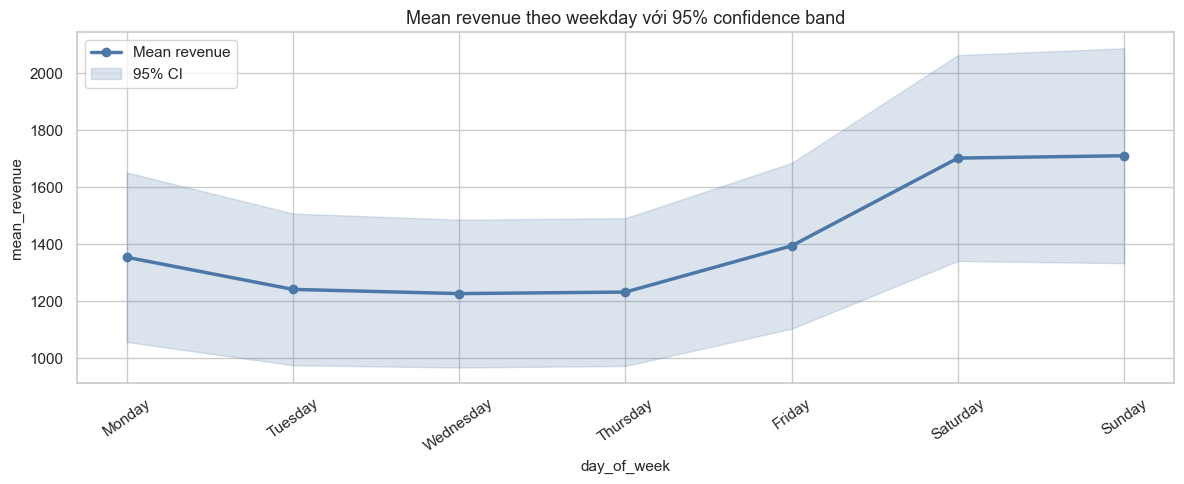

In [98]:
weekday_series_mean = (
    df_test.groupby(["store_id", "dept_id", "day_of_week"], as_index=False)
    .agg(mean_revenue=("daily_revenue", "mean"))
)

weekday_series_mean["day_of_week"] = pd.Categorical(
    weekday_series_mean["day_of_week"],
    categories=weekday_order,
    ordered=True
)

weekday_ci = (
    weekday_series_mean.groupby("day_of_week", observed=True)
    .agg(
        mean_revenue=("mean_revenue", "mean"),
        std_revenue=("mean_revenue", "std"),
        n_series=("mean_revenue", "size")
    )
    .reset_index()
)

weekday_ci["se"] = weekday_ci["std_revenue"] / np.sqrt(weekday_ci["n_series"])
weekday_ci["t_crit"] = stats.t.ppf(0.975, weekday_ci["n_series"] - 1)
weekday_ci["ci_95_low"] = weekday_ci["mean_revenue"] - weekday_ci["t_crit"] * weekday_ci["se"]
weekday_ci["ci_95_high"] = weekday_ci["mean_revenue"] + weekday_ci["t_crit"] * weekday_ci["se"]

display(weekday_ci)

x = np.arange(len(weekday_ci))

plt.figure(figsize=(12, 5))

plt.plot(
    x,
    weekday_ci["mean_revenue"],
    marker="o",
    linewidth=2.5,
    color="#4C78A8",
    label="Mean revenue"
)

plt.fill_between(
    x,
    weekday_ci["ci_95_low"],
    weekday_ci["ci_95_high"],
    color="#4C78A8",
    alpha=0.2,
    label="95% CI"
)

plt.xticks(x, weekday_ci["day_of_week"], rotation=35)
plt.title("Mean revenue theo weekday với 95% confidence band")
plt.xlabel("day_of_week")
plt.ylabel("mean_revenue")
plt.legend()
plt.tight_layout()
plt.show()

Cohen_dz: 0.97 
Doanh thu cuối tuần cao hơn ngày thường không chỉ về mặt trung bình, mà mức tăng này cũng đủ lớn và tương đối ổn định giữa các nhóm store-department. Vì vậy, is_weekend có thể là một feature quan trọng cho mô hình dự báo doanh thu.

paired_t_p: P-value của paired t-test. Kiểm định giả thuyết:
H0: mean_diff = 0
H1: mean_diff != 0
-> bác bỏ H0

statistic: 293.5408 
Đây là thống kê kiểm định Friedman. Số càng lớn thì khác biệt giữa 7 ngày càng rõ. Bản thân con số này ít cần diễn giải trực tiếp; quan trọng hơn là p_value.

p_value
H0: 7 ngày trong tuần có revenue giống nhau
H1: ít nhất một ngày khác biệt
P-value cực nhỏ nên bác bỏ H0.

**Đánh giá:** Weekend là tín hiệu rất chắc. Mean revenue weekend cao hơn weekday khoảng `416.5`, lift `32.3%`. Khi kiểm theo 70 chuỗi `store_id + dept_id`, cả 70/70 chuỗi đều có weekend cao hơn weekday; paired t-test p-value `1.12e-11`, Wilcoxon p-value `3.56e-13`, sign test p-value `1.69e-21`. Friedman test cho 7 weekday cũng rất mạnh, p-value `1.98e-60`.

**Quyết định tiếp theo:** Giữ `day_of_week_num` và `is_weekend` trong baseline model. Với forecasting, nên tạo thêm lag theo chu kỳ 7 ngày vì pattern tuần rõ ràng.

Các feature có thể thêm:

is_weekend bắt hiệu ứng cuối tuần.
day_of_week_num bắt pattern từng ngày.
revenue_lag_7 bắt tính lặp lại theo chu kỳ tuần.

,method,n_blocks,mean_diff,median_diff,ci_95_low,ci_95_high,cohen_dz,positive_blocks,negative_blocks,paired_t_p,wilcoxon_p,sign_test_p
0,paired by store_id + dept_id + month,840,414.9166,277.1506,385.1811,444.8019,0.9443,821,19,2.30e-118,1.39e-137,6.81e-215


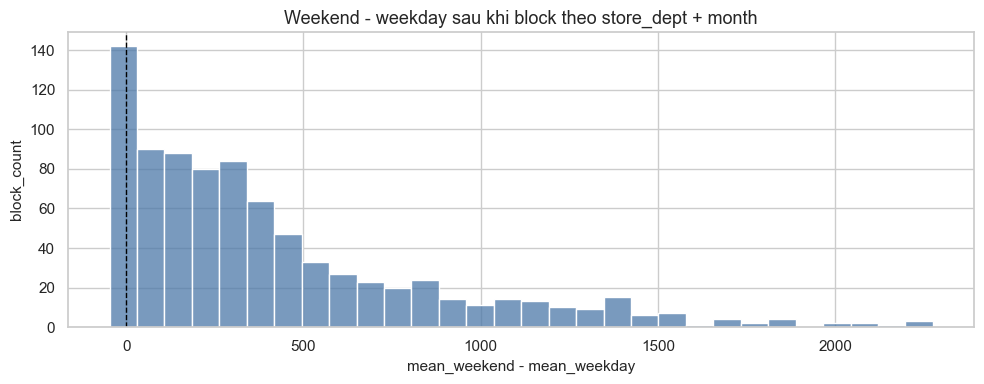

In [100]:
# Step 2: Weekend effect sau khi kiểm theo store_dept + month
# 70 store_dept x 12 tháng = 840 blocks
weekend_month_tests = blocked_binary_tests(
    df_test,
    "is_weekend",
    block_specs=[
        (
            "paired by store_id + dept_id + month",
            ["store_id", "dept_id", "month"]
        )
    ],
)

display(weekend_month_tests)

weekend_month_diff = binary_block_diff(
    df_test,
    "is_weekend",
    ["store_id", "dept_id", "month"]
)

plt.figure(figsize=(10, 4))
sns.histplot(weekend_month_diff, bins=30, color="#4C78A8")
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Weekend - weekday sau khi block theo store_dept + month")
plt.xlabel("mean_weekend - mean_weekday")
plt.ylabel("block_count")
plt.tight_layout()
plt.show()

Weekend effect không phải chỉ do tháng/seasonality. Nếu tháng nào đó doanh thu cao và vô tình có nhiều weekend, thì sau khi block theo month hiệu ứng sẽ giảm mạnh. Nhưng ở đây gần như không giảm: trước đó khoảng 416.5, sau khi kiểm month vẫn 414.9.

,method,n_blocks,mean_diff,median_diff,ci_95_low,ci_95_high,cohen_dz,positive_blocks,negative_blocks,paired_t_p,wilcoxon_p,sign_test_p
0,"paired by store_id + dept_id, non-event days only",70,421.7622,287.1974,320.9295,528.7021,0.9727,70,0,1.12e-11,3.56e-13,1.69e-21
1,"paired by store_id + dept_id + month, non-even...",840,421.0285,278.2075,390.8171,451.0954,0.9420,815,25,6.11e-118,1.00e-136,1.62e-205


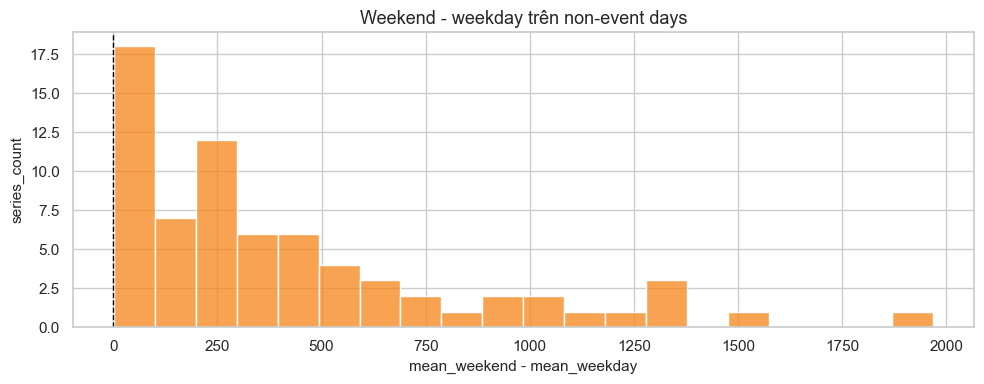

In [101]:
# Step 3: Weekend effect chỉ trên non-event days
df_no_event = df_test[df_test["has_event"] == 0].copy()

weekend_no_event_tests = blocked_binary_tests(
    df_no_event,
    "is_weekend",
    block_specs=[
        (
            "paired by store_id + dept_id, non-event days only",
            ["store_id", "dept_id"]
        ),
        (
            "paired by store_id + dept_id + month, non-event days only",
            ["store_id", "dept_id", "month"]
        ),
    ],
)

display(weekend_no_event_tests)

weekend_no_event_diff = binary_block_diff(
    df_no_event,
    "is_weekend",
    ["store_id", "dept_id"]
)

plt.figure(figsize=(10, 4))
sns.histplot(weekend_no_event_diff, bins=20, color="#F58518")
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Weekend - weekday trên non-event days")
plt.xlabel("mean_weekend - mean_weekday")
plt.ylabel("series_count")
plt.tight_layout()
plt.show()

Sau khi loại toàn bộ ngày có event/lễ, weekend vẫn cao hơn weekday khoảng 421.

Event/lễ không giải thích được weekend pattern. Weekend vẫn là tín hiệu riêng rất mạnh trên non-event days.

,method,n_blocks,mean_diff,median_diff,ci_95_low,ci_95_high,cohen_dz,positive_blocks,negative_blocks,paired_t_p,wilcoxon_p,sign_test_p,snap_group
0,"paired by store_id + dept_id, SNAP inactive",70,418.9156,276.5733,318.9328,525.1681,0.9688,70,0,1.28e-11,3.56e-13,1.69e-21,SNAP inactive
1,"paired by store_id + dept_id + month, SNAP ina...",840,417.6364,276.5731,387.8090,447.9078,0.9356,819,21,8.78e-117,4.22e-137,1.09e-211,SNAP inactive
2,"paired by store_id + dept_id, SNAP active",70,410.9530,282.8156,313.4107,514.0614,0.9783,69,1,9.17e-12,4.05e-13,1.20e-19,SNAP active
3,"paired by store_id + dept_id + month, SNAP active",840,406.8332,267.1850,376.8464,436.5889,0.9106,796,44,3.18e-112,1.66e-132,1.61e-179,SNAP active


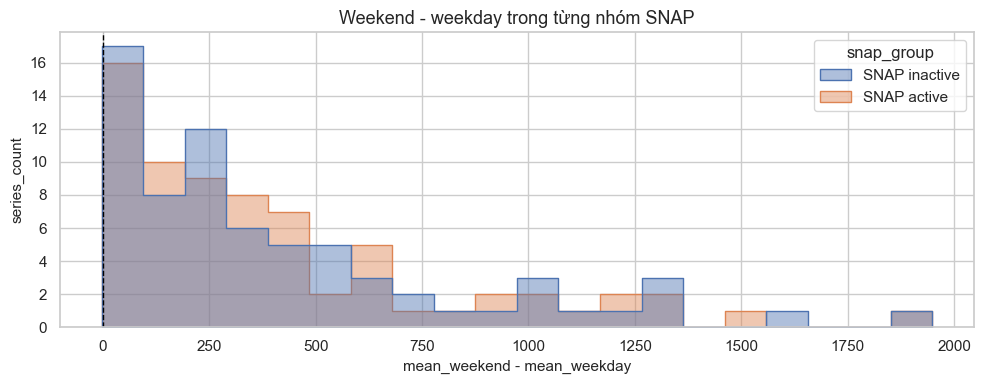

In [102]:
# Step 4: Weekend effect trong từng nhóm SNAP
snap_weekend_results = []

for snap_value, snap_label in [(0, "SNAP inactive"), (1, "SNAP active")]:
    df_snap_part = df_test[df_test["snap_active"] == snap_value].copy()

    test_result = blocked_binary_tests(
        df_snap_part,
        "is_weekend",
        block_specs=[
            (
                f"paired by store_id + dept_id, {snap_label}",
                ["store_id", "dept_id"]
            ),
            (
                f"paired by store_id + dept_id + month, {snap_label}",
                ["store_id", "dept_id", "month"]
            ),
        ],
    )

    test_result["snap_group"] = snap_label
    snap_weekend_results.append(test_result)

snap_weekend_tests = pd.concat(snap_weekend_results, ignore_index=True)
display(snap_weekend_tests)

# Vẽ phân phối weekend diff cho SNAP inactive vs active
snap_diff_plot_rows = []

for snap_value, snap_label in [(0, "SNAP inactive"), (1, "SNAP active")]:
    df_snap_part = df_test[df_test["snap_active"] == snap_value].copy()

    diff = binary_block_diff(
        df_snap_part,
        "is_weekend",
        ["store_id", "dept_id"]
    )

    temp = diff.reset_index(name="mean_diff")
    temp["snap_group"] = snap_label
    snap_diff_plot_rows.append(temp)

snap_diff_plot = pd.concat(snap_diff_plot_rows, ignore_index=True)

plt.figure(figsize=(10, 4))
sns.histplot(
    data=snap_diff_plot,
    x="mean_diff",
    hue="snap_group",
    bins=20,
    alpha=0.45,
    element="step"
)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Weekend - weekday trong từng nhóm SNAP")
plt.xlabel("mean_weekend - mean_weekday")
plt.ylabel("series_count")
plt.tight_layout()
plt.show()

Weekend effect tồn tại ở cả hai nhóm:
SNAP inactive
SNAP active
Mức chênh lệch cũng khá gần nhau:
SNAP inactive: ~419
SNAP active:   ~411

SNAP không phải nguyên nhân chính tạo ra weekend effect. Weekend cao hơn weekday cả khi SNAP active lẫn inactive.

Weekend là một tín hiệu dự báo rất ổn định. Nó không chỉ do khác biệt store/dept, không chỉ do seasonality theo tháng, không chỉ do event/lễ, và không chỉ do SNAP.

#### 10.2. Insight: SNAP active day có làm doanh thu khác biệt không?

**Chọn phương pháp:** SNAP là biến chính sách/lịch, có thể bị lẫn với state và mùa. So sánh thô chưa đủ, nên dùng:

- Bảng/biểu đồ SNAP active vs inactive.
- Kiểm định paired theo từng `store_id + dept_id`.
- Kiểm định thêm theo `store_id + dept_id + month` để giảm confound theo mùa.

,snap_active,row_count,mean_revenue,median_revenue,std_revenue,group_label
0,0,91070,"1,357.7685",962.3150,"1,320.2328",SNAP inactive
1,1,44800,"1,516.1957","1,043.9600","1,500.3956",SNAP active


,method,mean_diff_active_minus_inactive,lift_pct,p_value
0,raw row-level Welch t-test,158.4272,11.6682,1.80e-80


,month,snap_active,mean_revenue,row_count
0,1,0,"1,354.7626",7560
1,1,1,"1,482.3857",3500
2,2,0,"1,382.5022",7700
3,2,1,"1,521.0582",4200
4,3,0,"1,376.1931",8820
5,3,1,"1,527.6115",4200
6,4,0,"1,374.7001",8400
7,4,1,"1,540.1948",4200
8,5,0,"1,361.0120",8190
9,5,1,"1,523.7661",4200


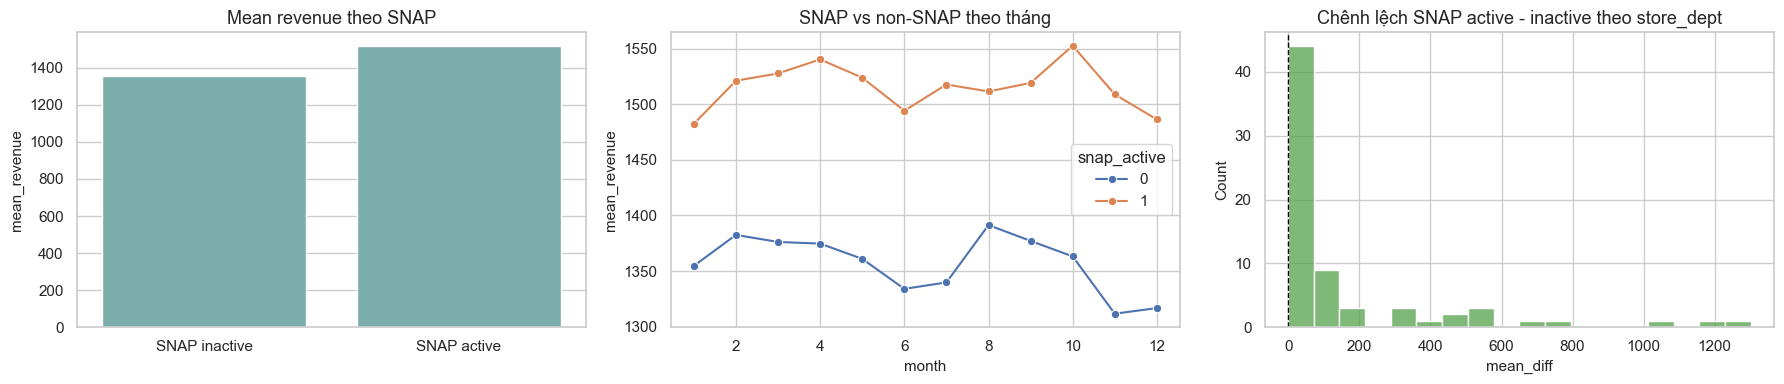

In [103]:
snap_summary, snap_raw_test = binary_group_summary(
    df_test,
    "snap_active",
    inactive_label="SNAP inactive",
    active_label="SNAP active",
)
snap_month_summary = (
    df_test.groupby(["month", "snap_active"], as_index=False)
    .agg(mean_revenue=("daily_revenue", "mean"), row_count=("daily_revenue", "size"))
)
snap_series_diff = binary_block_diff(df_test, "snap_active", ["store_id", "dept_id"])

display(snap_summary)
display(snap_raw_test)
display(snap_month_summary.head(12))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.barplot(data=snap_summary, x="group_label", y="mean_revenue", color="#72B7B2", ax=axes[0])
axes[0].set_title("Mean revenue theo SNAP")
axes[0].set_xlabel("")
axes[0].set_ylabel("mean_revenue")

sns.lineplot(data=snap_month_summary, x="month", y="mean_revenue", hue="snap_active", marker="o", ax=axes[1])
axes[1].set_title("SNAP vs non-SNAP theo tháng")
axes[1].set_xlabel("month")
axes[1].set_ylabel("mean_revenue")
axes[1].legend(title="snap_active")

sns.histplot(snap_series_diff, bins=18, color="#54A24B", ax=axes[2])
axes[2].axvline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Chênh lệch SNAP active - inactive theo store_dept")
axes[2].set_xlabel("mean_diff")

plt.tight_layout()
plt.show()

Biểu đồ giữa so sánh SNAP active vs non-SNAP theo từng tháng
Qua biểu đồ thấy SNAP active > SNAP inactive trong hầu hết/tất cả tháng
Nghĩa là tín hiệu SNAP khá ổn định theo tháng, không chỉ là seasonality đơn giản
Ở biểu đồ bên phải, ta thấy mean lớn hơn median rất nhiều, nghĩa là SNAP effect bị kéo lên bởi một số chuỗi có mức tăng rất mạnh. Nói cách khác, SNAP có tính hiệu dương, nhưng không đồng đều như weekend effect
65/70 store_dept dương
median_diff chỉ 35.2
một số chuỗi tăng rất mạnh kéo mean lên

In [104]:
snap_tests = blocked_binary_tests(
    df_test,
    "snap_active",
    block_specs=[
        ("paired by store_id + dept_id", ["store_id", "dept_id"]),
        ("paired by store_id + dept_id + month", ["store_id", "dept_id", "month"]),
    ],
)
display(snap_tests)

,method,n_blocks,mean_diff,median_diff,ci_95_low,ci_95_high,cohen_dz,positive_blocks,negative_blocks,paired_t_p,wilcoxon_p,sign_test_p
0,paired by store_id + dept_id,70,158.4272,35.2260,96.7846,226.9550,0.5656,65,5,1.14e-05,1.29e-12,2.22e-14
1,paired by store_id + dept_id + month,840,158.4602,38.2951,139.7162,178.4425,0.5504,659,181,3.16e-50,1.06e-81,1.62e-64


In [105]:
snap_dept_effect = (
    df_test.groupby(["dept_id", "snap_active"])["daily_revenue"]
    .mean()
    .unstack("snap_active")
    .rename(columns={0: "snap_inactive_mean", 1: "snap_active_mean"})
    .reset_index()
)

snap_dept_effect["mean_diff"] = (
    snap_dept_effect["snap_active_mean"]
    - snap_dept_effect["snap_inactive_mean"]
)

snap_dept_effect["lift_pct"] = (
    snap_dept_effect["snap_active_mean"]
    / snap_dept_effect["snap_inactive_mean"]
    - 1
) * 100

display(snap_dept_effect.sort_values("mean_diff", ascending=False))

snap_active,dept_id,snap_inactive_mean,snap_active_mean,mean_diff,lift_pct
2,FOODS_3,"3,548.8672","4,089.8597",540.9925,15.2441
1,FOODS_2,"1,182.4728","1,595.0617",412.5889,34.8920
5,HOUSEHOLD_1,"2,146.6905","2,219.4273",72.7367,3.3883
0,FOODS_1,668.7038,703.4312,34.7273,5.1932
3,HOBBIES_1,"1,129.7226","1,159.7739",30.0513,2.6601
6,HOUSEHOLD_2,766.1346,783.7011,17.5666,2.2929
4,HOBBIES_2,61.7882,62.1149,0.3267,0.5287


In [106]:
snap_state_effect = (
    df_test.groupby(["state_id", "snap_active"])["daily_revenue"]
    .mean()
    .unstack("snap_active")
    .rename(columns={0: "snap_inactive_mean", 1: "snap_active_mean"})
    .reset_index()
)

snap_state_effect["mean_diff"] = (
    snap_state_effect["snap_active_mean"]
    - snap_state_effect["snap_inactive_mean"]
)

snap_state_effect["lift_pct"] = (
    snap_state_effect["snap_active_mean"]
    / snap_state_effect["snap_inactive_mean"]
    - 1
) * 100

display(snap_state_effect.sort_values("mean_diff", ascending=False))

snap_active,state_id,snap_inactive_mean,snap_active_mean,mean_diff,lift_pct
2,WI,"1,159.9589","1,398.6837",238.7248,20.5805
1,TX,"1,305.5875","1,447.2236",141.6361,10.8485
0,CA,"1,545.2615","1,656.0587",110.7972,7.1701


In [107]:
snap_store_effect = (
    df_test.groupby(["store_id", "snap_active"])["daily_revenue"]
    .mean()
    .unstack("snap_active")
    .rename(columns={0: "snap_inactive_mean", 1: "snap_active_mean"})
    .reset_index()
)

snap_store_effect["mean_diff"] = (
    snap_store_effect["snap_active_mean"]
    - snap_store_effect["snap_inactive_mean"]
)

snap_store_effect["lift_pct"] = (
    snap_store_effect["snap_active_mean"]
    / snap_store_effect["snap_inactive_mean"]
    - 1
) * 100

display(snap_store_effect.sort_values("mean_diff", ascending=False))

snap_active,store_id,snap_inactive_mean,snap_active_mean,mean_diff,lift_pct
8,WI_2,"1,207.3297","1,593.0433",385.7136,31.9477
9,WI_3,"1,177.5984","1,456.6378",279.0394,23.6956
2,CA_3,"2,332.2614","2,557.8646",225.6032,9.6732
0,CA_1,"1,638.1259","1,793.7212",155.5952,9.4984
6,TX_3,"1,290.6503","1,436.6845",146.0342,11.3148
5,TX_2,"1,490.9080","1,632.8801",141.9720,9.5225
4,TX_1,"1,135.2042","1,272.1064",136.9022,12.0597
7,WI_1,"1,094.9485","1,146.3700",51.4214,4.6962
3,CA_4,904.9420,942.9511,38.0091,4.2002
1,CA_2,"1,305.7168","1,329.6979",23.9811,1.8366


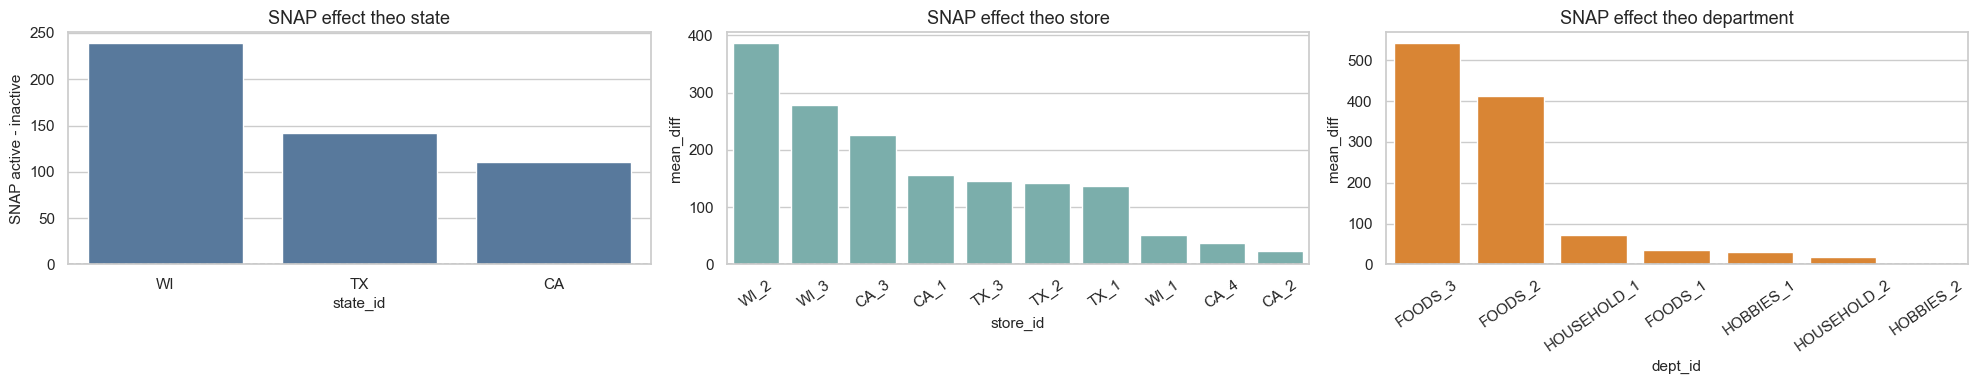

In [108]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4))

sns.barplot(
    data=snap_state_effect.sort_values("mean_diff", ascending=False),
    x="state_id",
    y="mean_diff",
    color="#4C78A8",
    ax=axes[0]
)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("SNAP effect theo state")
axes[0].set_ylabel("SNAP active - inactive")

sns.barplot(
    data=snap_store_effect.sort_values("mean_diff", ascending=False),
    x="store_id",
    y="mean_diff",
    color="#72B7B2",
    ax=axes[1]
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("SNAP effect theo store")
axes[1].tick_params(axis="x", rotation=35)

sns.barplot(
    data=snap_dept_effect.sort_values("mean_diff", ascending=False),
    x="dept_id",
    y="mean_diff",
    color="#F58518",
    ax=axes[2]
)
axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_title("SNAP effect theo department")
axes[2].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

- Tức là SNAP active days ở WI có mức tăng revenue mạnh hơn CA/TX. Điều này hợp lý vì SNAP là chương trình theo bang/ngày áp dụng, nên tác động có thể khác nhau theo state.
- Điều này cho thấy ngay trong cùng một dataset, SNAP active không làm tăng revenue đều nhau ở mọi store.
- Biểu đồ 3: Điều này rất hợp lý về mặt business: SNAP liên quan đến hỗ trợ mua thực phẩm, nên nhóm thực phẩm phản ứng mạnh hơn household/hobbies. SNAP effect chủ yếu là food-driven.
- Từ biểu đồ này, ta rút ra: SNAP effect có interaction rõ với state, store và department.
- SNAP active days có revenue cao hơn, nhưng effect không đồng đều. 
Tín hiệu SNAP mạnh nhất ở WI, một số store như WI_2/WI_3/CA_3, và tập trung chủ yếu ở FOODS_3/FOODS_2. 
- Do đó SNAP nên được giữ như feature, nhưng cần modeling interaction với state/store/dept hoặc dùng tree-based model có khả năng học interaction.

**Đánh giá:** SNAP có tín hiệu dương và khá ổn định. So sánh thô cho lift khoảng `11.7%`. Khi kiểm theo `store_id + dept_id`, mean diff là `158.4`, CI `[96.8, 227.0]`, paired t-test p-value `1.14e-05`; 65/70 chuỗi có SNAP cao hơn. Khi kiểm thêm theo tháng, mean diff vẫn khoảng `158.5`, CI `[139.7, 178.4]`.

**Quyết định tiếp theo:** Giữ `snap_active` trong model. Tuy nhiên vì SNAP là feature lịch/chính sách, cần làm ablation sau baseline để đo nó có cải thiện validation thật không, không chỉ dựa vào p-value.

#### 10.3. Insight: Event day có liên quan đến revenue không?

**Chọn phương pháp:** Event day không đồng nhất: có National, Religious, Sporting, Cultural. Vì vậy ta kiểm theo hai hướng:

- Binary `has_event` vs non-event, có block theo `store_id + dept_id`, thêm block theo tháng và weekday.
- So sánh `event_type_1_clean` bằng Kruskal-Wallis vì revenue lệch phải và event type có phân phối không đều.

,has_event,row_count,mean_revenue,median_revenue,std_revenue,group_label
0,0,124810,"1,414.8775",990.6700,"1,382.0737",no event
1,1,11060,"1,355.0346",916.9150,"1,407.2820",event


,method,mean_diff_active_minus_inactive,lift_pct,p_value
0,raw row-level Welch t-test,-59.8429,-4.2295,1.78e-05


,event_type_1_clean,mean_revenue,median_revenue,row_count
3,Sporting,"1,440.0270",996.2450,1120
0,Cultural,"1,435.3638",999.2350,2590
2,Religious,"1,416.6783",998.0350,3780
4,no_event,"1,414.8775",990.6700,124810
1,National,"1,204.8225",738.4700,3570


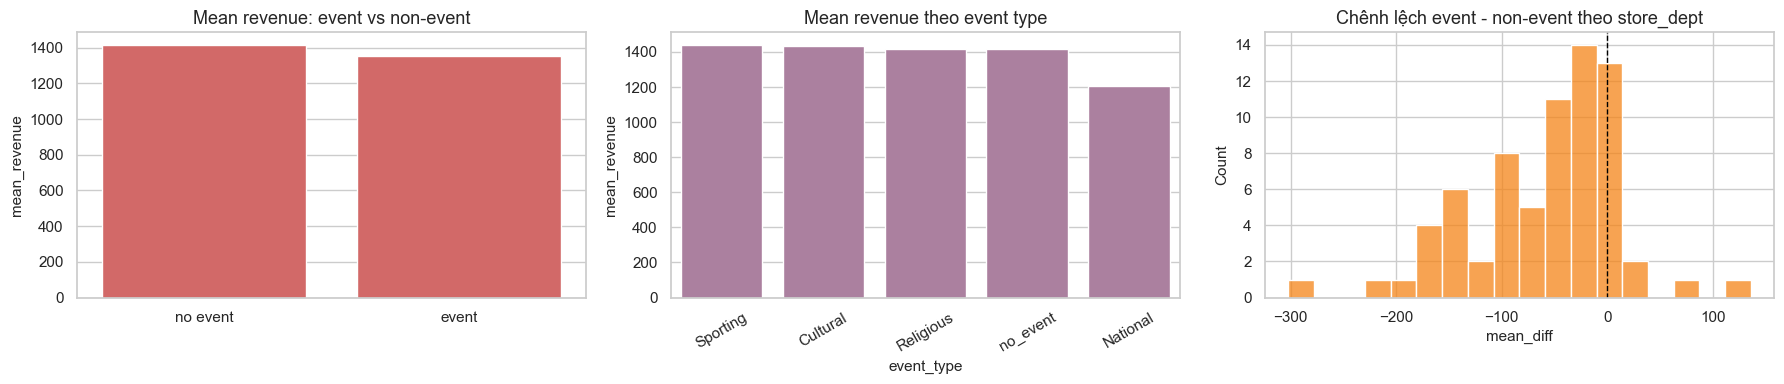

In [37]:
event_summary, event_raw_test = binary_group_summary(
    df_test,
    "has_event",
    inactive_label="no event",
    active_label="event",
)
event_type_summary = (
    df_test.groupby("event_type_1_clean", as_index=False)
    .agg(mean_revenue=("daily_revenue", "mean"), median_revenue=("daily_revenue", "median"), row_count=("daily_revenue", "size"))
    .sort_values("mean_revenue", ascending=False)
)
event_series_diff = binary_block_diff(df_test, "has_event", ["store_id", "dept_id"])

display(event_summary)
display(event_raw_test)
display(event_type_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.barplot(data=event_summary, x="group_label", y="mean_revenue", color="#E45756", ax=axes[0])
axes[0].set_title("Mean revenue: event vs non-event")
axes[0].set_xlabel("")
axes[0].set_ylabel("mean_revenue")

sns.barplot(data=event_type_summary, x="event_type_1_clean", y="mean_revenue", color="#B279A2", ax=axes[1])
axes[1].set_title("Mean revenue theo event type")
axes[1].set_xlabel("event_type")
axes[1].set_ylabel("mean_revenue")
axes[1].tick_params(axis="x", rotation=30)

sns.histplot(event_series_diff, bins=18, color="#F58518", ax=axes[2])
axes[2].axvline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Chênh lệch event - non-event theo store_dept")
axes[2].set_xlabel("mean_diff")

plt.tight_layout()
plt.show()

In [38]:
event_tests = blocked_binary_tests(
    df_test,
    "has_event",
    block_specs=[
        ("paired by store_id + dept_id", ["store_id", "dept_id"]),
        ("paired by store_id + dept_id + month", ["store_id", "dept_id", "month"]),
        ("paired by store_id + dept_id + weekday", ["store_id", "dept_id", "day_of_week"]),
    ],
)

event_type_groups = [group["daily_revenue"].to_numpy() for _, group in df_test.groupby("event_type_1_clean")]
event_type_kruskal = stats.kruskal(*event_type_groups)
event_type_test = pd.DataFrame({
    "method": ["Kruskal-Wallis across event_type_1_clean"],
    "n_groups": [df_test["event_type_1_clean"].nunique()],
    "statistic": [event_type_kruskal.statistic],
    "p_value": [event_type_kruskal.pvalue],
})
event_type_test["statistic"] = event_type_test["statistic"].round(4)
event_type_test["p_value"] = event_type_test["p_value"].map(format_p_value)

display(event_tests)
display(event_type_test)

,method,n_blocks,mean_diff,median_diff,ci_95_low,ci_95_high,cohen_dz,positive_blocks,negative_blocks,paired_t_p,wilcoxon_p,sign_test_p
0,paired by store_id + dept_id,70,-59.8429,-46.2397,-76.6027,-43.2663,-0.8476,6,64,9.08e-10,2.66e-10,2.44e-13
1,paired by store_id + dept_id + month,840,-80.9552,-16.0731,-105.1116,-58.9503,-0.2381,322,518,1.01e-11,1.51e-12,1.40e-11
2,paired by store_id + dept_id + weekday,490,-77.7536,-45.9630,-93.1291,-62.9351,-0.4635,127,363,1.68e-22,1.95e-28,2.30e-27


,method,n_groups,statistic,p_value
0,Kruskal-Wallis across event_type_1_clean,5,232.0127,4.87e-49


**Đánh giá:** Event day có doanh thu thấp hơn non-event trong dữ liệu này, nhưng đây là tín hiệu lịch, không phải kết luận event gây giảm doanh thu. Binary test theo `store_id + dept_id` cho mean diff `-59.8`, CI `[-76.6, -43.3]`, p-value `9.08e-10`; 64/70 chuỗi thấp hơn vào event day. Khi kiểm thêm theo tháng và weekday, diff vẫn âm. Event type cũng khác nhau rõ theo Kruskal-Wallis p-value `4.87e-49`; National thấp nhất trong bảng summary.

**Quyết định tiếp theo:** Giữ `has_event` và `event_type_1_clean`. Không nên chỉ dùng một biến event binary nếu model có đủ dữ liệu, vì event type có pattern khác nhau.

#### 10.4. Insight: Department, store và tổ hợp store-department có khác biệt lớn không?

**Chọn phương pháp:** Đây là insight về hierarchy/scale. Với dữ liệu panel, p-value trên toàn bộ dòng gần như chắc chắn nhỏ, nên trọng tâm là **effect size**:

- ANOVA/Kruskal trên toàn bộ dòng để đo khác biệt mô tả.
- Eta squared để xem group giải thích bao nhiêu variance.
- Kiểm thêm trên mean của 70 chuỗi `store_id + dept_id` để giảm ảnh hưởng số dòng thời gian lặp.

,dept_id,mean_revenue,median_revenue,total_revenue
2,FOODS_3,"3,727.2470","3,440.6800","72,345,863.7778"
5,HOUSEHOLD_1,"2,170.6738","1,963.5200","42,132,778.5504"
1,FOODS_2,"1,318.5145","1,226.6250","25,592,365.6414"
3,HOBBIES_1,"1,139.6314","1,025.9850","22,120,244.5109"
6,HOUSEHOLD_2,771.9267,653.3250,"14,983,097.8670"
0,FOODS_1,680.1544,631.0450,"13,201,796.0601"
4,HOBBIES_2,61.8959,55.7650,"1,201,399.7070"


,store_id,mean_revenue,median_revenue,total_revenue
2,CA_3,"2,406.6488","1,692.8200","32,699,137.6831"
0,CA_1,"1,689.4299","1,231.9300","22,954,283.7756"
5,TX_2,"1,537.7200","1,092.2900","20,893,002.1948"
6,TX_3,"1,338.8017",938.1500,"18,190,298.6966"
8,WI_2,"1,334.5098",765.8500,"18,131,985.0430"
1,CA_2,"1,313.6240","1,089.1200","17,848,209.3906"
9,WI_3,"1,269.6052",779.9600,"17,250,126.1765"
4,TX_1,"1,180.3445",795.7500,"16,037,341.1457"
7,WI_1,"1,111.9036",877.0700,"15,107,433.8073"
3,CA_4,917.4747,711.1000,"12,465,728.2013"


,store_id,dept_id,daily_revenue
16,CA_3,FOODS_3,"6,409.7467"
2,CA_1,FOODS_3,"4,801.7736"
37,TX_2,FOODS_3,"4,210.2480"
19,CA_3,HOUSEHOLD_1,"4,046.9080"
65,WI_3,FOODS_3,"3,770.8726"
58,WI_2,FOODS_3,"3,459.0810"
44,TX_3,FOODS_3,"3,426.4341"
30,TX_1,FOODS_3,"3,149.1756"
9,CA_2,FOODS_3,"2,917.5535"
51,WI_1,FOODS_3,"2,699.7858"


,store_id,dept_id,daily_revenue
18,CA_3,HOBBIES_2,89.1239
39,TX_2,HOBBIES_2,82.1075
46,TX_3,HOBBIES_2,79.7739
11,CA_2,HOBBIES_2,69.2147
4,CA_1,HOBBIES_2,63.7112
53,WI_1,HOBBIES_2,57.0313
32,TX_1,HOBBIES_2,52.9457
60,WI_2,HOBBIES_2,49.3807
67,WI_3,HOBBIES_2,49.0698
25,CA_4,HOBBIES_2,26.6005


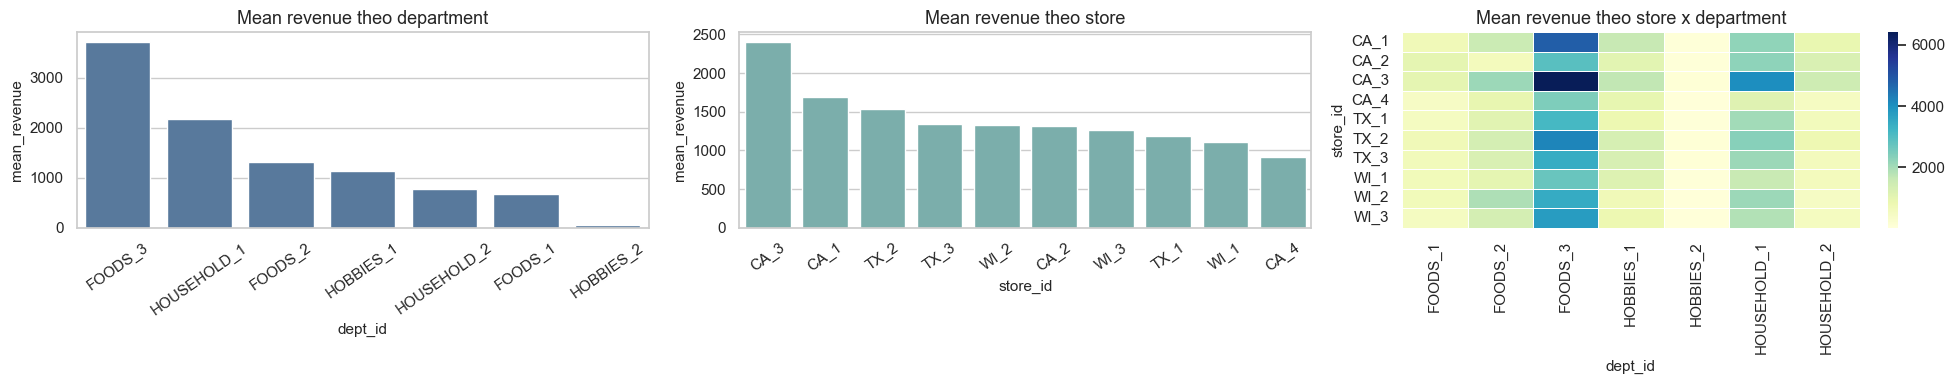

In [39]:
dept_summary_test = (
    df_test.groupby("dept_id", as_index=False)
    .agg(mean_revenue=("daily_revenue", "mean"), median_revenue=("daily_revenue", "median"), total_revenue=("daily_revenue", "sum"))
    .sort_values("mean_revenue", ascending=False)
)
store_summary_test = (
    df_test.groupby("store_id", as_index=False)
    .agg(mean_revenue=("daily_revenue", "mean"), median_revenue=("daily_revenue", "median"), total_revenue=("daily_revenue", "sum"))
    .sort_values("mean_revenue", ascending=False)
)
store_dept_mean_test = (
    df_test.groupby(["store_id", "dept_id"], as_index=False)["daily_revenue"]
    .mean()
    .sort_values("daily_revenue", ascending=False)
)

display(dept_summary_test)
display(store_summary_test)
display(store_dept_mean_test.head(10))
display(store_dept_mean_test.tail(10))

fig, axes = plt.subplots(1, 3, figsize=(20, 4))
sns.barplot(data=dept_summary_test, x="dept_id", y="mean_revenue", color="#4C78A8", ax=axes[0])
axes[0].set_title("Mean revenue theo department")
axes[0].set_xlabel("dept_id")
axes[0].set_ylabel("mean_revenue")
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(data=store_summary_test, x="store_id", y="mean_revenue", color="#72B7B2", ax=axes[1])
axes[1].set_title("Mean revenue theo store")
axes[1].set_xlabel("store_id")
axes[1].set_ylabel("mean_revenue")
axes[1].tick_params(axis="x", rotation=35)

store_dept_heatmap_test = store_dept_mean_test.pivot(index="store_id", columns="dept_id", values="daily_revenue")
sns.heatmap(store_dept_heatmap_test, cmap="YlGnBu", linewidths=0.4, linecolor="white", ax=axes[2])
axes[2].set_title("Mean revenue theo store x department")
axes[2].set_xlabel("dept_id")
axes[2].set_ylabel("store_id")

plt.tight_layout()
plt.show()

In [40]:
hierarchy_row_tests = pd.DataFrame([
    group_effect_on_rows(df_test, "dept_id"),
    group_effect_on_rows(df_test, "store_id"),
    group_effect_on_rows(df_test, "store_dept"),
])

series_mean = (
    df_test.groupby(["store_id", "dept_id", "state_id", "cat_id"], as_index=False)["daily_revenue"]
    .mean()
)
series_level_tests = []
for group_col in ["dept_id", "store_id"]:
    groups = [group["daily_revenue"].to_numpy() for _, group in series_mean.groupby(group_col)]
    anova = stats.f_oneway(*groups)
    kruskal = stats.kruskal(*groups)

    overall_mean = series_mean["daily_revenue"].mean()
    group_stats = series_mean.groupby(group_col)["daily_revenue"].agg(["mean", "size"])
    ss_between = ((group_stats["mean"] - overall_mean) ** 2 * group_stats["size"]).sum()
    ss_total = ((series_mean["daily_revenue"] - overall_mean) ** 2).sum()

    level_mean = group_stats["mean"].sort_values(ascending=False)
    series_level_tests.append({
        "group_col": group_col,
        "n_series_rows": len(series_mean),
        "eta_squared_on_series_mean": ss_between / ss_total,
        "anova_p": anova.pvalue,
        "kruskal_p": kruskal.pvalue,
        "top_level": level_mean.index[0],
        "top_mean": level_mean.iloc[0],
        "bottom_level": level_mean.index[-1],
        "bottom_mean": level_mean.iloc[-1],
    })
series_level_tests = pd.DataFrame(series_level_tests)

display_test_table(hierarchy_row_tests)
display_test_table(series_level_tests)

,group_col,n_levels,eta_squared,anova_p,kruskal_p,top_level,top_mean,bottom_level,bottom_mean,mean_range
0,dept_id,7,0.6551,<1e-300,<1e-300,FOODS_3,"3,727.2470",HOBBIES_2,61.8959,"3,665.3511"
1,store_id,10,0.0789,<1e-300,<1e-300,CA_3,"2,406.6488",CA_4,917.4747,"1,489.1742"
2,store_dept,70,0.8183,<1e-300,<1e-300,CA_3_FOODS_3,"6,409.7467",CA_4_HOBBIES_2,26.6005,"6,383.1462"


,group_col,n_series_rows,eta_squared_on_series_mean,anova_p,kruskal_p,top_level,top_mean,bottom_level,bottom_mean
0,dept_id,70,0.8005,3.12e-20,7.24e-11,FOODS_3,"3,727.2470",HOBBIES_2,61.8959
1,store_id,70,0.0964,0.6963,0.8239,CA_3,"2,406.6488",CA_4,917.4747


**Đánh giá:** Hierarchy là tín hiệu lớn nhất trong dữ liệu. Trên toàn bộ dòng, `dept_id` có eta squared `0.655`, `store_dept` có eta squared `0.818`; nghĩa là scale revenue khác nhau rất mạnh theo nhóm sản phẩm và tổ hợp store-department. `FOODS_3` cao nhất, `HOBBIES_2` thấp nhất; `CA_3_FOODS_3` là chuỗi lớn nhất. Khi giảm dữ liệu về 70 mean chuỗi, `dept_id` vẫn cực mạnh (`eta_squared_on_series_mean = 0.801`, ANOVA p-value `3.12e-20`). Store có khác biệt mean, nhưng test trên 70 chuỗi không còn mạnh vì department effect chi phối và số chuỗi mỗi store ít.

**Quyết định tiếp theo:** Model bắt buộc phải có `dept_id`, `store_id`, và nên tạo lag/rolling riêng theo `store_id + dept_id`. Không nên train một mô hình chỉ nhìn calendar mà bỏ hierarchy.

#### 10.5. Insight: Weather có nên đưa vào model không?

**Chọn phương pháp:** Weather rất dễ bị confound với state, month và weekday. Nếu chỉ nhìn correlation raw thì dễ kết luận sai. Vì vậy ta dùng:

- Correlation raw ở mức `state-date`.
- Correlation sau khi residualize cả revenue và weather theo `state + month + weekday`.
- Riêng rain dùng thêm kiểm định binary theo từng `store_id + dept_id`.

,weather_feature,raw_pearson_r,raw_pearson_p,raw_spearman_r,raw_spearman_p,resid_pearson_r,resid_pearson_p,resid_spearman_r,resid_spearman_p
0,temperature_mean_c,0.1787,5.64e-43,0.1607,5.44e-35,0.0169,0.1974,0.0150,0.2515
1,precipitation_mm,-0.1086,9.76e-17,-0.1977,2.16e-52,-0.0091,0.4875,0.0048,0.7133
2,wind_speed_max_kmh,-0.4034,7.18e-227,-0.4391,3.77e-273,-0.0580,9.37e-06,-0.0511,9.51e-05


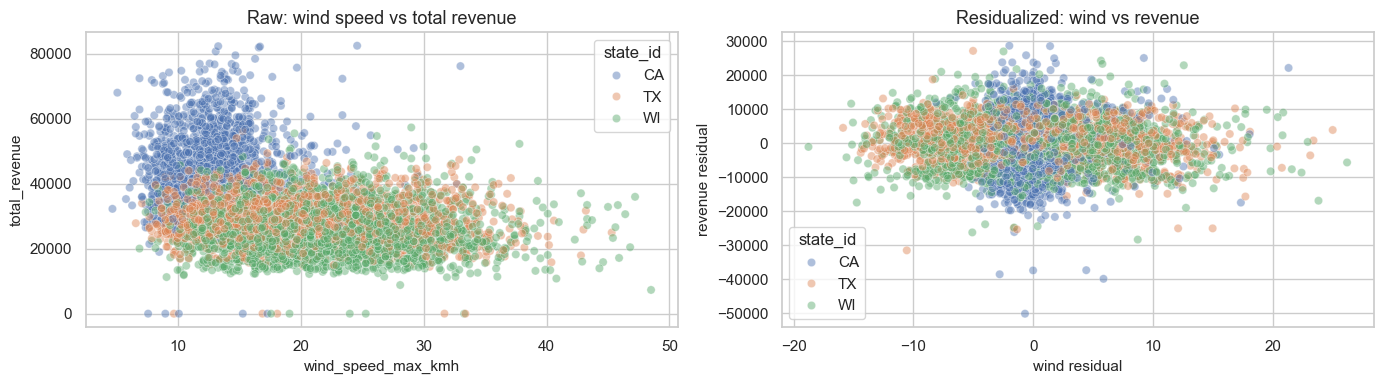

In [41]:
weather_daily = (
    df_test.groupby(["date", "state_id"], as_index=False)
    .agg(
        total_revenue=("daily_revenue", "sum"),
        temperature_mean_c=("temperature_mean_c", "mean"),
        precipitation_mm=("precipitation_mm", "mean"),
        wind_speed_max_kmh=("wind_speed_max_kmh", "mean"),
    )
)
weather_daily["month"] = weather_daily["date"].dt.month
weather_daily["day_of_week_num"] = weather_daily["date"].dt.dayofweek
weather_daily["state_month_weekday"] = (
    weather_daily["state_id"] + "_" + weather_daily["month"].astype(str) + "_" + weather_daily["day_of_week_num"].astype(str)
)


def residualize_by_group(data, col, group_col):
    return data[col] - data.groupby(group_col)[col].transform("mean")

weather_corr_rows = []
for col in ["temperature_mean_c", "precipitation_mm", "wind_speed_max_kmh"]:
    raw_pearson = stats.pearsonr(weather_daily[col], weather_daily["total_revenue"])
    raw_spearman = stats.spearmanr(weather_daily[col], weather_daily["total_revenue"])

    x_resid = residualize_by_group(weather_daily, col, "state_month_weekday")
    y_resid = residualize_by_group(weather_daily, "total_revenue", "state_month_weekday")
    resid_pearson = stats.pearsonr(x_resid, y_resid)
    resid_spearman = stats.spearmanr(x_resid, y_resid)

    weather_corr_rows.append({
        "weather_feature": col,
        "raw_pearson_r": raw_pearson.statistic,
        "raw_pearson_p": raw_pearson.pvalue,
        "raw_spearman_r": raw_spearman.statistic,
        "raw_spearman_p": raw_spearman.pvalue,
        "resid_pearson_r": resid_pearson.statistic,
        "resid_pearson_p": resid_pearson.pvalue,
        "resid_spearman_r": resid_spearman.statistic,
        "resid_spearman_p": resid_spearman.pvalue,
    })
weather_corr_tests = pd.DataFrame(weather_corr_rows)

weather_corr_display = weather_corr_tests.copy()
for col in weather_corr_display.columns:
    if col.endswith("_r"):
        weather_corr_display[col] = weather_corr_display[col].round(4)
    if col.endswith("_p"):
        weather_corr_display[col] = weather_corr_display[col].map(format_p_value)

display(weather_corr_display)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.scatterplot(data=weather_daily, x="wind_speed_max_kmh", y="total_revenue", hue="state_id", alpha=0.45, ax=axes[0])
axes[0].set_title("Raw: wind speed vs total revenue")
axes[0].set_xlabel("wind_speed_max_kmh")
axes[0].set_ylabel("total_revenue")

weather_daily["wind_resid"] = residualize_by_group(weather_daily, "wind_speed_max_kmh", "state_month_weekday")
weather_daily["revenue_resid"] = residualize_by_group(weather_daily, "total_revenue", "state_month_weekday")
sns.scatterplot(data=weather_daily, x="wind_resid", y="revenue_resid", hue="state_id", alpha=0.45, ax=axes[1])
axes[1].set_title("Residualized: wind vs revenue")
axes[1].set_xlabel("wind residual")
axes[1].set_ylabel("revenue residual")

plt.tight_layout()
plt.show()

,is_rainy_day,row_count,mean_revenue,median_revenue,std_revenue,group_label
0,0,94619,"1,438.5464","1,014.0500","1,418.0789",no rain
1,1,41251,"1,344.5425",920.3200,"1,300.9416",rainy


,method,mean_diff_active_minus_inactive,lift_pct,p_value
0,raw row-level Welch t-test,-94.0040,-6.5346,1.09e-32


,method,n_blocks,mean_diff,median_diff,ci_95_low,ci_95_high,cohen_dz,positive_blocks,negative_blocks,paired_t_p,wilcoxon_p,sign_test_p
0,paired by store_id + dept_id,70,5.3800,8.0784,-5.5099,15.1944,0.1215,46,24,0.3128,0.0241,0.0115


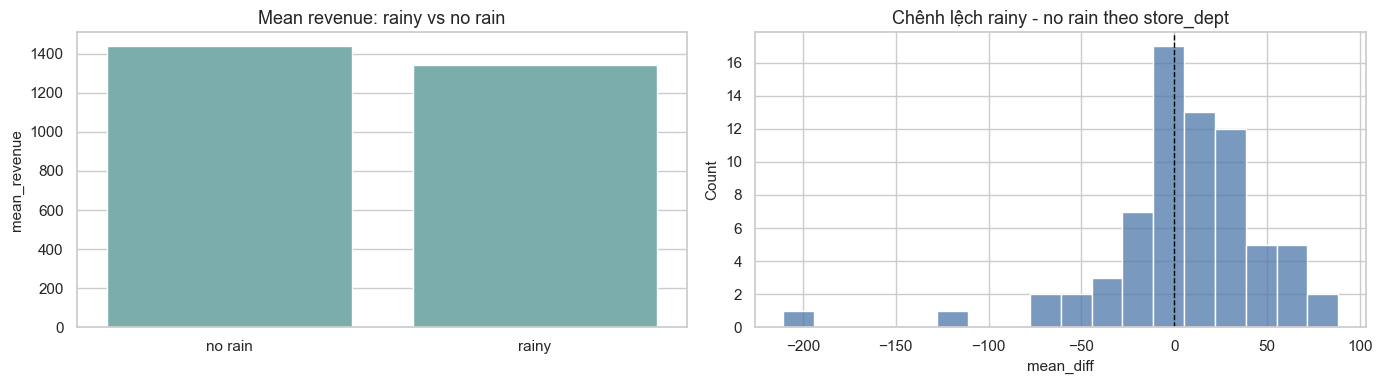

In [42]:
rain_summary, rain_raw_test = binary_group_summary(
    df_test,
    "is_rainy_day",
    inactive_label="no rain",
    active_label="rainy",
)
rain_tests = blocked_binary_tests(
    df_test,
    "is_rainy_day",
    block_specs=[("paired by store_id + dept_id", ["store_id", "dept_id"])],
)
rain_series_diff = binary_block_diff(df_test, "is_rainy_day", ["store_id", "dept_id"])

display(rain_summary)
display(rain_raw_test)
display(rain_tests)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=rain_summary, x="group_label", y="mean_revenue", color="#72B7B2", ax=axes[0])
axes[0].set_title("Mean revenue: rainy vs no rain")
axes[0].set_xlabel("")
axes[0].set_ylabel("mean_revenue")

sns.histplot(rain_series_diff, bins=18, color="#4C78A8", ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Chênh lệch rainy - no rain theo store_dept")
axes[1].set_xlabel("mean_diff")

plt.tight_layout()
plt.show()

**Đánh giá:** Weather là tín hiệu yếu sau khi kiểm soát thô theo lịch/vị trí. Raw correlation cho wind khá mạnh (`Spearman = -0.439`), nhưng sau khi residualize theo `state + month + weekday`, wind chỉ còn `Spearman = -0.051`; temperature và precipitation gần như mất tín hiệu. Rain cũng cho thấy confound: so sánh thô rainy thấp hơn khoảng `94.0`, nhưng khi kiểm theo `store_id + dept_id`, mean diff chỉ `+5.4`, CI `[-5.5, 15.2]`, paired t-test p-value `0.3128`.

**Quyết định tiếp theo:** Không đưa weather vào baseline đầu tiên. Weather nên là nhóm feature ablation sau khi đã có baseline mạnh với calendar + hierarchy + lag/rolling.

#### 10.6. Insight: Outlier revenue có phải lỗi để xóa không?

**Chọn phương pháp:** EDA cho thấy outlier tập trung ở `FOODS_3` và `CA_3`. Cần kiểm tra outlier có phụ thuộc vào hierarchy không:

- Xác định outlier theo IQR như phần EDA.
- Dùng chi-square independence test giữa outlier flag và `dept_id`/`store_id`.
- Dùng Cramer's V để đo cường độ liên hệ, vì p-value với dữ liệu lớn rất dễ nhỏ.

,metric,value
0,upper_bound,"4,000.2037"
1,outlier_rows,"8,194.0000"
2,outlier_rate,0.0603


,group_col,chi2,dof,p_value,cramers_v
0,dept_id,"35,239.5777",6,<1e-300,0.5093
1,store_id,"7,930.0857",9,<1e-300,0.2416


,dept_id,base_share,outlier_share,lift_vs_base
2,FOODS_3,0.1429,0.8352,5.8467
5,HOUSEHOLD_1,0.1429,0.1494,1.0456
1,FOODS_2,0.1429,0.0154,0.1076
0,FOODS_1,0.1429,0.0000,0.0000
3,HOBBIES_1,0.1429,0.0000,0.0000
4,HOBBIES_2,0.1429,0.0000,0.0000
6,HOUSEHOLD_2,0.1429,0.0000,0.0000


,store_id,base_share,outlier_share,lift_vs_base
2,CA_3,0.1000,0.3423,3.4232
0,CA_1,0.1000,0.1781,1.7806
5,TX_2,0.1000,0.1325,1.3254
8,WI_2,0.1000,0.1032,1.0325
9,WI_3,0.1000,0.0843,0.8433
6,TX_3,0.1000,0.0563,0.5626
1,CA_2,0.1000,0.0359,0.3588
7,WI_1,0.1000,0.0347,0.3466
4,TX_1,0.1000,0.0326,0.3258
3,CA_4,0.1000,0.0001,0.0012


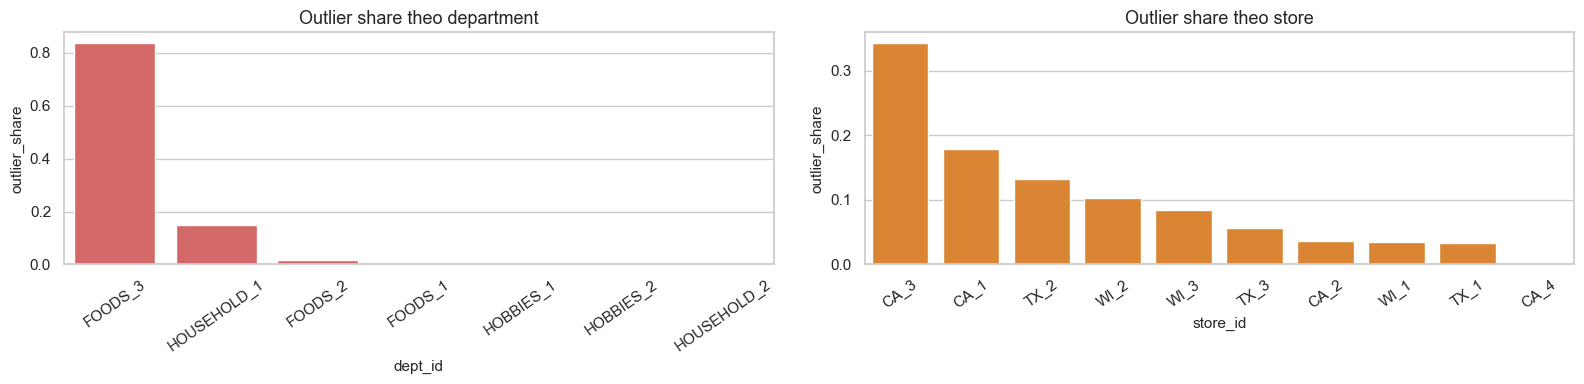

In [43]:
q1 = df_test["daily_revenue"].quantile(0.25)
q3 = df_test["daily_revenue"].quantile(0.75)
iqr = q3 - q1
outlier_upper = q3 + 1.5 * iqr

df_test["is_revenue_outlier"] = (df_test["daily_revenue"] > outlier_upper).astype(int)
outlier_summary_test = pd.DataFrame({
    "metric": ["upper_bound", "outlier_rows", "outlier_rate"],
    "value": [outlier_upper, df_test["is_revenue_outlier"].sum(), df_test["is_revenue_outlier"].mean()],
})


def outlier_group_test(data, group_col):
    table = pd.crosstab(data["is_revenue_outlier"], data[group_col])
    chi2, p_value, dof, expected = stats.chi2_contingency(table)
    n = table.to_numpy().sum()
    rows, cols = table.shape
    cramers_v = np.sqrt(chi2 / (n * min(rows - 1, cols - 1)))

    outlier_share = data.loc[data["is_revenue_outlier"] == 1, group_col].value_counts(normalize=True)
    base_share = data[group_col].value_counts(normalize=True)
    share_table = pd.DataFrame({"base_share": base_share, "outlier_share": outlier_share}).fillna(0)
    share_table["lift_vs_base"] = share_table["outlier_share"] / share_table["base_share"]
    share_table = share_table.reset_index(names=group_col).sort_values("outlier_share", ascending=False)

    test_row = {
        "group_col": group_col,
        "chi2": chi2,
        "dof": dof,
        "p_value": p_value,
        "cramers_v": cramers_v,
    }
    return test_row, share_table

outlier_dept_test, outlier_dept_share = outlier_group_test(df_test, "dept_id")
outlier_store_test, outlier_store_share = outlier_group_test(df_test, "store_id")
outlier_tests = pd.DataFrame([outlier_dept_test, outlier_store_test])

outlier_tests_display = outlier_tests.copy()
outlier_tests_display["chi2"] = outlier_tests_display["chi2"].round(4)
outlier_tests_display["cramers_v"] = outlier_tests_display["cramers_v"].round(4)
outlier_tests_display["p_value"] = outlier_tests_display["p_value"].map(format_p_value)

for table in [outlier_dept_share, outlier_store_share]:
    for col in ["base_share", "outlier_share", "lift_vs_base"]:
        table[col] = table[col].round(4)

display(outlier_summary_test)
display(outlier_tests_display)
display(outlier_dept_share)
display(outlier_store_share.head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.barplot(data=outlier_dept_share, x="dept_id", y="outlier_share", color="#E45756", ax=axes[0])
axes[0].set_title("Outlier share theo department")
axes[0].set_xlabel("dept_id")
axes[0].set_ylabel("outlier_share")
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(data=outlier_store_share.head(10), x="store_id", y="outlier_share", color="#F58518", ax=axes[1])
axes[1].set_title("Outlier share theo store")
axes[1].set_xlabel("store_id")
axes[1].set_ylabel("outlier_share")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

**Đánh giá:** Outlier không giống lỗi ngẫu nhiên. Outlier rate khoảng `6.03%`, upper bound khoảng `4000.2`. Chi-square cho `dept_id` và outlier có p-value `<1e-300`, Cramer's V `0.509`, mức liên hệ khá mạnh; `FOODS_3` chiếm `83.5%` outlier dù base share chỉ `14.3%`. Store cũng có liên hệ, Cramer's V `0.242`; `CA_3` chiếm `34.2%` outlier.

**Quyết định tiếp theo:** Không xóa outlier tự động. Đây là doanh thu thật của các chuỗi scale lớn. Khi modeling, xử lý bằng feature hierarchy, metric robust, hoặc thử `log1p(daily_revenue)`/loss robust nếu model nhạy với outlier.

### 11. Hành động tiếp theo: tạo modeling dataset và baseline kiểm chứng

Sau các kiểm định, hướng đi hợp lý không phải thêm mọi feature ngay lập tức. Ta tạo baseline có những tín hiệu chắc nhất:

- Calendar: `day_of_week_num`, `is_weekend`, month/week.
- Hierarchy: `store_id`, `state_id`, `cat_id`, `dept_id`.
- Event/SNAP: giữ vì có tín hiệu sau kiểm định.
- History: lag/rolling theo `store_id + dept_id`, vì forecasting cần lịch sử riêng của từng chuỗi.
- Weather: để riêng làm ablation, không đưa vào baseline đầu tiên.

In [44]:
model_df = df_eda.sort_values(["store_id", "dept_id", "date"]).copy()
model_df["event_type_1_clean"] = model_df["event_type_1"].fillna("no_event")
series_key = ["store_id", "dept_id"]

for lag in [7, 28]:
    model_df[f"revenue_lag_{lag}"] = model_df.groupby(series_key)["daily_revenue"].shift(lag)

for window in [7, 28]:
    model_df[f"revenue_roll_{window}_mean"] = model_df.groupby(series_key)["daily_revenue"].transform(
        lambda series: series.shift(1).rolling(window).mean()
    )

calendar_feature_cols = [
    "year", "month", "quarter", "week_of_year", "day_of_month",
    "day_of_year", "day_of_week_num", "is_weekend"
]
hierarchy_feature_cols = ["store_id", "state_id", "cat_id", "dept_id"]
event_snap_feature_cols = ["has_event", "event_type_1_clean", "snap_active"]
history_feature_cols = [
    "revenue_lag_7", "revenue_lag_28",
    "revenue_roll_7_mean", "revenue_roll_28_mean"
]
weather_feature_cols = ["temperature_mean_c", "precipitation_mm", "wind_speed_max_kmh"]

feature_cols_v1 = calendar_feature_cols + hierarchy_feature_cols + event_snap_feature_cols + history_feature_cols
feature_cols_with_weather = feature_cols_v1 + weather_feature_cols

max_date = model_df["date"].max()
valid_start = max_date - pd.Timedelta(days=27)
model_ready = model_df.dropna(subset=history_feature_cols).copy()
train_df = model_ready[model_ready["date"] < valid_start].copy()
valid_df = model_ready[model_ready["date"] >= valid_start].copy()

model_dataset_summary = pd.DataFrame({
    "metric": ["max_date", "valid_start", "model_ready_rows", "train_rows", "valid_rows", "series_count"],
    "value": [max_date.date(), valid_start.date(), len(model_ready), len(train_df), len(valid_df), model_ready.groupby(series_key).ngroups],
})
feature_plan = pd.DataFrame({
    "feature_group": ["calendar", "hierarchy", "event_snap", "history", "weather_ablation"],
    "columns": [calendar_feature_cols, hierarchy_feature_cols, event_snap_feature_cols, history_feature_cols, weather_feature_cols],
    "decision": [
        "Giữ trong baseline vì weekday/weekend có kiểm định mạnh.",
        "Giữ bắt buộc vì dept/store_dept có effect size lớn.",
        "Giữ, sau đó đo ablation riêng cho SNAP/event.",
        "Giữ bắt buộc cho forecasting; shift trước rolling để tránh leakage.",
        "Chỉ thêm sau baseline để kiểm tra có cải thiện thật không.",
    ],
})

display(model_dataset_summary)
display(feature_plan)
display(model_ready[["date", "store_id", "dept_id", "daily_revenue"] + history_feature_cols].head(10))

print("Target:", "daily_revenue")
print("Feature cols v1:", feature_cols_v1)
print("Feature cols with weather:", feature_cols_with_weather)

,metric,value
0,max_date,2016-05-22
1,valid_start,2016-04-25
2,model_ready_rows,133910
3,train_rows,131950
4,valid_rows,1960
5,series_count,70


,feature_group,columns,decision
0,calendar,"[year, month, quarter, week_of_year, day_of_mo...",Giữ trong baseline vì weekday/weekend có kiểm ...
1,hierarchy,"[store_id, state_id, cat_id, dept_id]",Giữ bắt buộc vì dept/store_dept có effect size...
2,event_snap,"[has_event, event_type_1_clean, snap_active]","Giữ, sau đó đo ablation riêng cho SNAP/event."
3,history,"[revenue_lag_7, revenue_lag_28, revenue_roll_7...",Giữ bắt buộc cho forecasting; shift trước roll...
4,weather_ablation,"[temperature_mean_c, precipitation_mm, wind_sp...",Chỉ thêm sau baseline để kiểm tra có cải thiện...


,date,store_id,dept_id,daily_revenue,revenue_lag_7,revenue_lag_28,revenue_roll_7_mean,revenue_roll_28_mean
1960,2011-02-26,CA_1,FOODS_1,719.5800,627.5200,681.1800,512.3743,559.0625
2030,2011-02-27,CA_1,FOODS_1,603.7500,619.1400,643.6900,525.5257,560.4339
2100,2011-02-28,CA_1,FOODS_1,438.2000,544.1200,451.1400,523.3271,559.0075
2170,2011-03-01,CA_1,FOODS_1,612.3600,380.0400,400.3900,508.1957,558.5454
2240,2011-03-02,CA_1,FOODS_1,442.7300,398.6800,396.3600,541.3843,566.1157
2310,2011-03-03,CA_1,FOODS_1,484.1100,487.3200,434.4000,547.6771,567.7718
2380,2011-03-04,CA_1,FOODS_1,607.5100,529.8000,575.8100,547.2186,569.5471
2450,2011-03-05,CA_1,FOODS_1,754.9700,719.5800,586.1500,558.3200,570.6793
2520,2011-03-06,CA_1,FOODS_1,743.0100,603.7500,595.4700,563.3757,576.7086
2590,2011-03-07,CA_1,FOODS_1,390.5500,438.2000,405.6300,583.2700,581.9779


Target: daily_revenue
Feature cols v1: ['year', 'month', 'quarter', 'week_of_year', 'day_of_month', 'day_of_year', 'day_of_week_num', 'is_weekend', 'store_id', 'state_id', 'cat_id', 'dept_id', 'has_event', 'event_type_1_clean', 'snap_active', 'revenue_lag_7', 'revenue_lag_28', 'revenue_roll_7_mean', 'revenue_roll_28_mean']
Feature cols with weather: ['year', 'month', 'quarter', 'week_of_year', 'day_of_month', 'day_of_year', 'day_of_week_num', 'is_weekend', 'store_id', 'state_id', 'cat_id', 'dept_id', 'has_event', 'event_type_1_clean', 'snap_active', 'revenue_lag_7', 'revenue_lag_28', 'revenue_roll_7_mean', 'revenue_roll_28_mean', 'temperature_mean_c', 'precipitation_mm', 'wind_speed_max_kmh']


#### 11.1. Baseline validation đơn giản để biết mốc cần vượt qua

Trước khi train model phức tạp, cần một baseline time-series rõ ràng. Ta dùng 28 ngày cuối làm validation và so sánh vài dự báo đơn giản: lag 7, lag 28, rolling mean và historical mean theo `store_id + dept_id + weekday`.

,baseline,MAE,RMSE,WAPE,sMAPE
1,lag_28,256.8151,405.0060,0.1290,0.1786
5,blend_lag7_roll28,265.9589,437.6301,0.1336,0.1546
0,lag_7,281.0512,479.6001,0.1412,0.1730
2,roll_7_mean,326.5500,520.3307,0.1641,0.1758
3,roll_28_mean,327.7538,532.8851,0.1647,0.1774
4,series_dow_mean,587.9236,859.3916,0.2954,0.3677


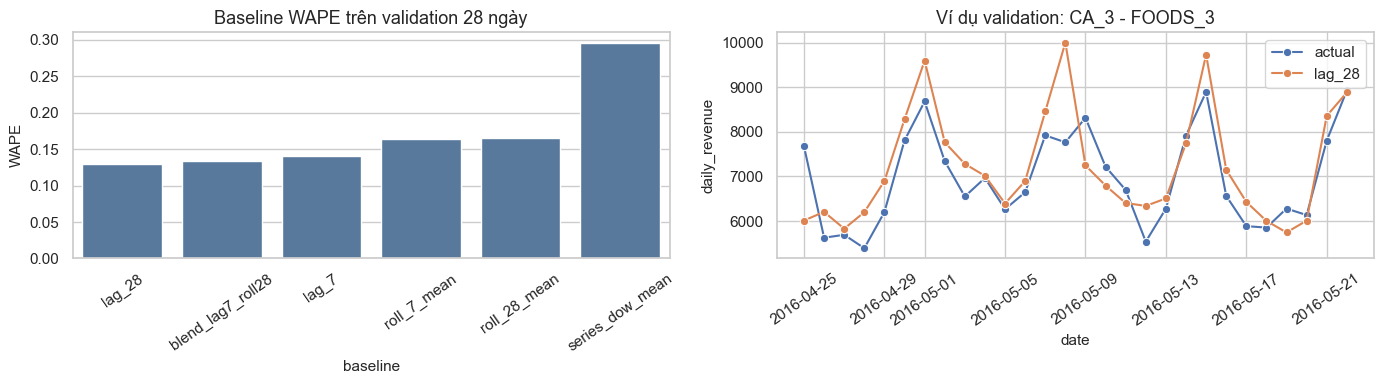

In [45]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    error = y_pred - y_true
    return {
        "MAE": np.mean(np.abs(error)),
        "RMSE": np.sqrt(np.mean(error ** 2)),
        "WAPE": np.sum(np.abs(error)) / np.sum(np.abs(y_true)),
        "sMAPE": np.mean(2 * np.abs(error) / (np.abs(y_true) + np.abs(y_pred) + 1e-9)),
    }

series_dow_mean = (
    train_df.groupby(["store_id", "dept_id", "day_of_week_num"])["daily_revenue"]
    .mean()
    .rename("pred_series_dow_mean")
    .reset_index()
)
valid_eval = valid_df.merge(series_dow_mean, on=["store_id", "dept_id", "day_of_week_num"], how="left")
valid_eval["pred_blend_lag7_roll28"] = (valid_eval["revenue_lag_7"] + valid_eval["revenue_roll_28_mean"]) / 2

baseline_pred_cols = {
    "lag_7": "revenue_lag_7",
    "lag_28": "revenue_lag_28",
    "roll_7_mean": "revenue_roll_7_mean",
    "roll_28_mean": "revenue_roll_28_mean",
    "series_dow_mean": "pred_series_dow_mean",
    "blend_lag7_roll28": "pred_blend_lag7_roll28",
}

baseline_rows = []
for baseline_name, pred_col in baseline_pred_cols.items():
    row = {"baseline": baseline_name}
    row.update(regression_metrics(valid_eval["daily_revenue"], valid_eval[pred_col]))
    baseline_rows.append(row)

baseline_results = pd.DataFrame(baseline_rows).sort_values("MAE")
for col in ["MAE", "RMSE", "WAPE", "sMAPE"]:
    baseline_results[col] = baseline_results[col].round(4)

display(baseline_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=baseline_results, x="baseline", y="WAPE", color="#4C78A8", ax=axes[0])
axes[0].set_title("Baseline WAPE trên validation 28 ngày")
axes[0].set_xlabel("baseline")
axes[0].set_ylabel("WAPE")
axes[0].tick_params(axis="x", rotation=35)

sample_series = valid_eval[(valid_eval["store_id"] == "CA_3") & (valid_eval["dept_id"] == "FOODS_3")].copy()
sns.lineplot(data=sample_series, x="date", y="daily_revenue", marker="o", label="actual", ax=axes[1])
sns.lineplot(data=sample_series, x="date", y="revenue_lag_28", marker="o", label="lag_28", ax=axes[1])
axes[1].set_title("Ví dụ validation: CA_3 - FOODS_3")
axes[1].set_xlabel("date")
axes[1].set_ylabel("daily_revenue")
axes[1].tick_params(axis="x", rotation=35)
axes[1].legend()

plt.tight_layout()
plt.show()

**Kết luận hành động:** Baseline tốt nhất hiện tại là `lag_28` với MAE khoảng `256.8` và WAPE `0.129`. Điều này xác nhận historical lag là nhóm feature rất mạnh, phù hợp với kết quả kiểm định calendar/seasonality. Baseline này là mốc tối thiểu model ML phải vượt qua.

**Bước modeling tiếp theo nên làm:** Train model supervised theo `feature_cols_v1`, ưu tiên mô hình tree-based có xử lý nonlinear và categorical encoding rõ ràng. Sau đó chạy ablation theo thứ tự: baseline calendar+hierarchy+history, thêm SNAP/event, rồi mới thêm weather. Đánh giá bằng validation time-based 28 ngày và báo lỗi theo `dept_id`, `store_id`, top chuỗi lớn như `CA_3 + FOODS_3`.